# tSZ as a calibrator of baryonic feedback for weak lensing

**The systematic.** Baryonic feedback redistributes matter inside halos and
suppresses the small-scale matter power spectrum — the dominant astrophysical
systematic for cosmic-shear $S_8$ (DES, KiDS, HSC, LSST, Euclid). It is
degenerate with cosmology, and the leading idea to break that degeneracy is to
**calibrate feedback with the thermal Sunyaev–Zel'dovich effect** (DES×ACT,
Bigwood+24; baryonification, Schneider+).

**The open question.** *How tightly does an observable feedback proxy (tSZ
Compton-$Y$) predict the matter-power suppression, and with what irreducible
scatter?* Real surveys measure $Y$ and lensing on different objects/statistics.

**Why this tool.** BIND2 generates the tSZ observable $Y$ **and** the total
matter field $[\mathrm{DM}+\mathrm{Gas}+\mathrm{Stars}]$ for the *same* halo,
*same* cosmology, *same* feedback — so we can measure the
$Y \rightarrow$ suppression mapping directly and check it across the 35-D SB35
feedback grid.

**Standards of evidence.** Every reported number carries a bootstrap CI; every
relation is referenced against (i) the **CV null** — 27 fiducial sims that
isolate cosmic variance at fixed feedback, so the floor of irreducible
scatter is *measured, not assumed* — and (ii) **published suppression**
benchmarks (TNG, EAGLE, BAHAMAS, vD+20). Where BIND fails, we localize the
failure in §4.5 rather than averaging it away.

| § | Figure | Content |
|---|--------|---------|
| 1.5 | W0a | **Premise:** per-patch mass conservation (DMO vs hydro & BIND) |
| 1.7 | W0b | **Premise:** single-patch $P(k)$ noise floor → $k_{\rm reliable}$ |
| 1.8 | W0c | **Null:** CV-ensemble suppression band (cosmic-variance floor) |
| 2 | W1 | Stacked $P_{\rm hydro}/P_{\rm DMO}(k)$ by mass, with CV null & lit anchors |
| 2.5 | W1b | **Robustness:** aperture × mass cut × $k$-band sweep (does it hold?) |
| 3 | W2 | Profile ratio split by $Y$ tercile (with bootstrap bands & CV null) |
| 4 | W3 | Calibration: suppression vs $Y, T, P, f_{\rm gas}$ with bootstrap CIs |
| 4.5 | W3b | **Residuals:** where does BIND under/over-predict the suppression? |
| 5 | W4 | Predictive $R^2$: bootstrap CIs + leave-one-sim-out cross-validation |
| 6 | W5 | Full-box composite suppression vs population $Y$ (coverage-aware) |
| 6.5 | W5b | Anchor to **van Daalen+20** / TNG / EAGLE / BAHAMAS |
| 7 | **M** | **Money plot** — the $Y$→suppression law with CV floor & literature |
| 8 | — | Bootstrapped scorecard |

Patch geometry: 128² pix on a 6.25 Mpc/h tile (≈49 kpc/h/pix). $Y_{200}$ is
extensive; $T,P,S$ are gas-mass-weighted within $R_{200}$.


## 0. Setup

In [24]:
import io
import json
import sys
from contextlib import redirect_stdout
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, rankdata

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
from metrics import CHANNEL_NAMES, power_spectrum_2d
from data import THERMO_KEYS, N_THERMO

plt.rcParams.update({
    'font.size': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'axes.grid': False,
})
try:
    import scienceplots          # noqa: F401
    plt.style.use(['science', 'notebook'])
except Exception as exc:
    print(f'[scienceplots unavailable: {exc}]')

SUITE_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP       = 'snap_090'
MASS_TAG   = 'mass_threshold_1p000e13'
MODEL_NAME = 'fm_thermo_ema'
BOX_SIZE   = 50.0
N_PIX_FULL = 1024
PATCH_PIX  = 128
PATCH_BOX  = BOX_SIZE * PATCH_PIX / N_PIX_FULL   # 6.25 Mpc/h
PIX_MPC    = PATCH_BOX / PATCH_PIX
PIX_KPC    = PIX_MPC * 1000.0                    # 48.83 kpc/h / pix  (R200 units)
PIX_AREA_MPC2 = PIX_MPC ** 2
N_PARAMS   = 35
KMAX_PLOT  = 30.0                                # h/Mpc; above this single-patch P(k) is noise
PK_BAND    = (4.0, 15.0)                         # h/Mpc band for the scalar suppression metric
K_NYQ      = np.pi / PIX_MPC                     # ~64 h/Mpc Nyquist for patch pixels
SUPP_BAND  = (0.1, 0.5)                          # r/R200 band for the suppression scalar
BOOT_N     = 500                                 # bootstrap resamples (raise for paper-grade)
RNG        = np.random.default_rng(20250528)

THERMO_NAMES = list(THERMO_KEYS)
THERMO_SHORT = {'compton_y': 'Y', 'temperature': 'T', 'entropy': 'S', 'pressure': 'P'}
THERMO_LABELS = {'compton_y': r'Compton $y$', 'temperature': r'$T$',
                 'entropy': r'$S$', 'pressure': r'$P$'}

SUITES = ('CV', '1P', 'Test')
SUITE_COLORS  = {'CV': 'tab:green', '1P': 'tab:blue', 'Test': 'tab:red'}
SUITE_DISPLAY = {'CV': 'CV', '1P': '1P', 'Test': 'SB35'}

_param_meta = pd.read_csv(
    '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv')
PARAM_NAMES = {i + 1: name for i, name in enumerate(_param_meta['ParamName'])}
PARAM_LABELS = {1: r'$\Omega_m$', 2: r'$\sigma_8$', 3: r'$A_{\rm SN1}$',
                4: r'$A_{\rm SN2}$', 5: r'$A_{\rm AGN1}$', 6: r'$A_{\rm AGN2}$'}
for _i in range(7, N_PARAMS + 1):
    PARAM_LABELS[_i] = PARAM_NAMES.get(_i, f'p{_i}')

# Literature anchors for the matter-power suppression at z~0.
# van Daalen+2020 (CAMELS comparison), Schneider+2019 baryonification, BAHAMAS.
# Quoted as P_hydro/P_DMO at the listed k (h/Mpc) for ~TNG-like feedback.
LIT_SUPPRESSION = {
    'TNG100 (vD+20)':   {'k': 5.0,  'ratio': 0.93, 'k_strong': 10.0, 'ratio_strong': 0.83},
    'EAGLE (vD+20)':    {'k': 5.0,  'ratio': 0.90, 'k_strong': 10.0, 'ratio_strong': 0.78},
    'BAHAMAS T7.8':     {'k': 5.0,  'ratio': 0.88, 'k_strong': 10.0, 'ratio_strong': 0.75},
}

FIG_DIR = Path('tsz_wl_calibration_figs')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name, ext=('pdf', 'png')):
    for e in ext:
        out = FIG_DIR / f'{name}.{e}'
        fig.savefig(out)
        print(f'  wrote {out}')


def pk2d(field, box_size=PATCH_BOX):
    # Pylians Pk_plane prints per call; silence it. Returns (k, Pk).
    with redirect_stdout(io.StringIO()):
        return power_spectrum_2d(field, box_size=box_size)


# ----------------------- statistical rigor helpers -----------------------
def bootstrap_ci(values, stat=np.nanmedian, n_boot=BOOT_N, ci=(16, 84), rng=RNG):
    """Bootstrap CI of `stat(values)`. Returns (point, lo, hi)."""
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if v.size < 3:
        return float('nan'), float('nan'), float('nan')
    idx = rng.integers(0, v.size, size=(n_boot, v.size))
    samples = np.array([stat(v[i]) for i in idx])
    lo, hi = np.nanpercentile(samples, ci)
    return float(stat(v)), float(lo), float(hi)


def bootstrap_curve(curves, stat=np.nanmedian, n_boot=BOOT_N, ci=(16, 84), rng=RNG):
    """Bootstrap CI of a curve aggregator over rows. curves: (N_obj, N_k)."""
    a = np.asarray(curves, float)
    if a.size == 0:
        return None
    idx = rng.integers(0, a.shape[0], size=(n_boot, a.shape[0]))
    boot = np.stack([stat(a[i], axis=0) for i in idx])
    return {'point': stat(a, axis=0),
            'lo': np.nanpercentile(boot, ci[0], axis=0),
            'hi': np.nanpercentile(boot, ci[1], axis=0)}


def spearman_boot(x, y, n_boot=BOOT_N, rng=RNG):
    """Bootstrap CI on Spearman rho. Returns (rho, lo, hi)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 10:
        return float('nan'), float('nan'), float('nan')
    rho = spearmanr(x, y).correlation
    idx = rng.integers(0, x.size, size=(n_boot, x.size))
    rb = np.array([spearmanr(x[i], y[i]).correlation for i in idx])
    return float(rho), float(np.nanpercentile(rb, 16)), float(np.nanpercentile(rb, 84))


def partial_spearman(x, y, z):
    """Spearman(x,y) controlling for z, via rank-residuals."""
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    if m.sum() < 10:
        return float('nan')
    rx, ry, rz = rankdata(x[m]), rankdata(y[m]), rankdata(z[m])
    ax = rx - np.polyval(np.polyfit(rz, rx, 1), rz)
    ay = ry - np.polyval(np.polyfit(rz, ry, 1), rz)
    return float(spearmanr(ax, ay).correlation)


def partial_spearman_boot(x, y, z, n_boot=BOOT_N, rng=RNG):
    x, y, z = (np.asarray(v, float) for v in (x, y, z))
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[m], y[m], z[m]
    if x.size < 10:
        return float('nan'), float('nan'), float('nan')
    point = partial_spearman(x, y, z)
    idx = rng.integers(0, x.size, size=(n_boot, x.size))
    rb = np.array([partial_spearman(x[i], y[i], z[i]) for i in idx])
    return float(point), float(np.nanpercentile(rb, 16)), float(np.nanpercentile(rb, 84))


def ols_with_intrinsic_scatter(x, y, n_boot=BOOT_N, rng=RNG):
    """OLS y = a*x + b with intrinsic scatter sigma and bootstrap CIs on each."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 5:
        return {k: float('nan') for k in ('slope', 'intercept', 'sigma', 'n',
                                          'slope_lo', 'slope_hi',
                                          'intercept_lo', 'intercept_hi',
                                          'sigma_lo', 'sigma_hi')}
    a, b = np.polyfit(x, y, 1)
    sig = float(np.std(y - (a * x + b)))
    idx = rng.integers(0, x.size, size=(n_boot, x.size))
    boots = np.array([np.polyfit(x[i], y[i], 1) for i in idx])
    sigs  = np.array([np.std(y[i] - (boots[k, 0] * x[i] + boots[k, 1]))
                      for k, i in enumerate(idx)])
    return {'slope': float(a), 'intercept': float(b), 'sigma': sig, 'n': int(x.size),
            'slope_lo': float(np.percentile(boots[:, 0], 16)),
            'slope_hi': float(np.percentile(boots[:, 0], 84)),
            'intercept_lo': float(np.percentile(boots[:, 1], 16)),
            'intercept_hi': float(np.percentile(boots[:, 1], 84)),
            'sigma_lo': float(np.percentile(sigs, 16)),
            'sigma_hi': float(np.percentile(sigs, 84))}


def fmt_ci(point, lo, hi, fmt='.3f'):
    return f'{point:{fmt}} [{lo:{fmt}}, {hi:{fmt}}]'


def linmix_lite(x, y, sigma_y=None, n_boot=BOOT_N, rng=RNG):
    """MLE for y = a*x + b with intrinsic scatter sigma_int, optional sigma_y per point.\n    Profile likelihood over (a,b,sigma_int^2). Bootstrap CIs.\n    Returns dict with slope, intercept, sigma_int, sigma_total and CIs.\n    Reduces to OLS when sigma_y is None or all zero."""
    from scipy.optimize import minimize
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if sigma_y is None:
        sy = np.zeros_like(y)
    else:
        sy = np.asarray(sigma_y, float)[m]
        sy = np.where(np.isfinite(sy), sy, 0.0)
    if x.size < 5:
        return {k: float('nan') for k in
                ('slope', 'intercept', 'sigma_int', 'sigma_total', 'n',
                 'slope_lo', 'slope_hi', 'intercept_lo', 'intercept_hi',
                 'sigma_int_lo', 'sigma_int_hi')}

    def nll(theta, xx, yy, ss):
        a, b, log_s = theta
        s2 = np.exp(2 * log_s) + ss ** 2
        r = yy - (a * xx + b)
        return 0.5 * np.sum(np.log(2 * np.pi * s2) + r ** 2 / s2)

    def fit(xx, yy, ss):
        a0, b0 = np.polyfit(xx, yy, 1)
        s0 = float(np.std(yy - (a0 * xx + b0))) + 1e-6
        res = minimize(nll, [a0, b0, np.log(s0)], args=(xx, yy, ss),
                       method='Nelder-Mead', options={'xatol': 1e-5, 'fatol': 1e-7})
        a, b, ls = res.x
        return a, b, float(np.exp(ls))

    a, b, sint = fit(x, y, sy)
    boots = []
    idx_all = rng.integers(0, x.size, size=(n_boot, x.size))
    for ii in idx_all:
        try:
            boots.append(fit(x[ii], y[ii], sy[ii]))
        except Exception:
            boots.append((np.nan, np.nan, np.nan))
    boots = np.array(boots)
    pct = lambda v, q: float(np.nanpercentile(v, q))
    sigma_total = float(np.sqrt(sint ** 2 + np.mean(sy ** 2)))
    return {'slope': float(a), 'intercept': float(b),
            'sigma_int': float(sint), 'sigma_total': sigma_total, 'n': int(x.size),
            'slope_lo': pct(boots[:, 0], 16), 'slope_hi': pct(boots[:, 0], 84),
            'intercept_lo': pct(boots[:, 1], 16), 'intercept_hi': pct(boots[:, 1], 84),
            'sigma_int_lo': pct(boots[:, 2], 16), 'sigma_int_hi': pct(boots[:, 2], 84)}


def decompose_scatter(sigma_total, sigma_floor):
    """Quadrature decomposition: feedback-driven scatter above the CV floor.\n    Returns (sigma_feedback, fraction_floor)."""
    st, sf = float(sigma_total), float(sigma_floor)
    if not np.isfinite(st) or not np.isfinite(sf):
        return float('nan'), float('nan')
    diff2 = st ** 2 - sf ** 2
    return float(np.sqrt(max(diff2, 0.0))), float((sf / st) ** 2 if st > 0 else np.nan)


print('Patch box:', PATCH_BOX, 'Mpc/h  | pix', round(PIX_KPC, 2), 'kpc/h')
print(f'k_Nyquist (patch) ~ {K_NYQ:.1f} h/Mpc  | KMAX_PLOT={KMAX_PLOT} h/Mpc')
print(f'BOOT_N = {BOOT_N}')
print('Fig dir  :', FIG_DIR.resolve())


Patch box: 6.25 Mpc/h  | pix 48.83 kpc/h
k_Nyquist (patch) ~ 64.3 h/Mpc  | KMAX_PLOT=30.0 h/Mpc
BOOT_N = 500
Fig dir  : /mnt/home/mlee1/vdm_bind2/tsz_wl_calibration_figs


## 1. Loaders & the per-halo table

Per halo we assemble: $\log M_{200}$, $R_{200}$, the 35 params, the R200-aperture
thermo amplitudes ($Y$ extensive, $T/S/P$ gas-mass-weighted), the gas fraction
$f_{\rm gas}=M_{\rm gas}/M_{\rm tot}$ within $R_{200}$, and a **suppression
scalar** = mean of $\rho_{\rm hydro}/\rho_{\rm DMO}$ over $0.1$–$0.5\,R_{200}$
(<1 = net ejection, >1 = net contraction). Total matter is
$\mathrm{DM}+\mathrm{Gas}+\mathrm{Stars}$ (truth from `truth_maps`, BIND from
`generated[:, :3]`); DMO is `dmo_fullbox` extracted at the halo centre.

In [25]:
def sim_record(sim_dir, suite_name):
    snap, mass = sim_dir / SNAP, sim_dir / SNAP / MASS_TAG
    model = mass / MODEL_NAME
    rec = {'suite': suite_name, 'sim_id': sim_dir.name, 'sim_dir': sim_dir,
           'full_maps': snap / 'full_maps.npz', 'halo_catalog': mass / 'halo_catalog.npz',
           'truth_thermo': mass / 'truth_thermo_patches.npz',
           'generated': model / 'generated_halos.npz',
           'composite': model / 'composite.npz', 'summary': model / 'summary.json'}
    rec['available'] = all(rec[k].exists() for k in
                           ('full_maps', 'halo_catalog', 'truth_thermo', 'generated'))
    return rec


def discover_sims(suites=SUITES):
    recs = []
    for suite in suites:
        root = SUITE_ROOT / suite
        if not root.exists():
            print(f'[skip] {root} missing'); continue
        for sd in sorted(root.iterdir()):
            if sd.is_dir():
                recs.append(sim_record(sd, suite))
    return pd.DataFrame(recs)


def extract_patch(field_2d, cx, cy, size=PATCH_PIX):
    n = field_2d.shape[0]; half = size // 2
    ix = (cx - half + np.arange(size)) % n
    iy = (cy - half + np.arange(size)) % n
    return field_2d[np.ix_(ix, iy)]


def centers_to_pixels(centers_mpc):
    return (np.asarray(centers_mpc) * (N_PIX_FULL / BOX_SIZE)).astype(np.int64) % N_PIX_FULL


def load_full_maps(rec):
    d = np.load(rec['full_maps']); return d['dmo_fullbox'], d['truth_maps']


def load_catalog(rec):
    d = np.load(rec['halo_catalog'])
    return {'centers': d['centers'], 'masses': d['masses'], 'radii': d['radii'],
            'params': d['params'] if 'params' in d.files else None}


def load_generated(rec):
    return np.load(rec['generated'])['generated']        # (N,7,128,128)


def load_truth_thermo(rec):
    return np.load(rec['truth_thermo'])['truth_thermo']  # (N,4,128,128)


def load_summary(rec):
    if not rec['summary'].exists():
        return {}
    with open(rec['summary']) as f:
        return json.load(f)


sims_all = discover_sims()
print(sims_all.groupby('suite')['available'].agg(['sum', 'count']))
sims      = sims_all[sims_all['available']].reset_index(drop=True)
cv_sims   = sims[sims['suite'] == 'CV'].reset_index(drop=True)
oneP_sims = sims[sims['suite'] == '1P'].reset_index(drop=True)
test_sims = sims[sims['suite'] == 'Test'].reset_index(drop=True)
print(f'Available: CV={len(cv_sims)} 1P={len(oneP_sims)} SB35={len(test_sims)}')

       sum  count
suite            
1P     139    141
CV      27     27
Test   102    102
Available: CV=27 1P=139 SB35=102


In [26]:
_yy, _xx = np.mgrid[0:PATCH_PIX, 0:PATCH_PIX]
_RR = np.sqrt((_xx - PATCH_PIX / 2.0) ** 2 + (_yy - PATCH_PIX / 2.0) ** 2)
RAD_GRID = np.linspace(0.05, 1.5, 30)            # r / R200 grid for stacked profiles


def radial_profile_2d(arr, rmax=None):
    ny, nx = arr.shape
    cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0
    y, x = np.indices(arr.shape)
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(int)
    if rmax is None:
        rmax = r.max()
    m = (r <= rmax) & np.isfinite(arr)
    sums = np.bincount(r[m].ravel(), weights=arr[m].ravel(), minlength=rmax + 1)
    cnt  = np.bincount(r[m].ravel(), minlength=rmax + 1)
    prof = np.full(rmax + 1, np.nan); good = cnt > 0
    prof[good] = sums[good] / cnt[good]
    return np.arange(rmax + 1), prof


def load_wl_patches(rec):
    cat = load_catalog(rec)
    dmo_full, truth_maps = load_full_maps(rec)
    gen = load_generated(rec)
    tt = load_truth_thermo(rec)
    cp = centers_to_pixels(cat['centers'])
    n = len(cp)
    dmo       = np.stack([extract_patch(dmo_full, cx, cy) for cx, cy in cp]).astype(np.float32)
    truth_tot = np.stack([sum(extract_patch(truth_maps[c], cx, cy) for c in range(3))
                          for cx, cy in cp]).astype(np.float32)
    truth_gas = np.stack([extract_patch(truth_maps[1], cx, cy) for cx, cy in cp]).astype(np.float32)
    return {'dmo': dmo, 'truth_tot': truth_tot, 'gen_tot': gen[:, :3].sum(1),
            'truth_gas': truth_gas, 'gen_gas': gen[:, 1],
            'truth_th': tt, 'gen_th': gen[:, 3:],
            'masses': cat['masses'], 'radii': cat['radii'], 'params': cat['params']}


def _profile_ratio(num, den, r200_pix):
    # ratio num/den interpolated onto RAD_GRID (= r/R200)
    r, pn = radial_profile_2d(num); _, pd_ = radial_profile_2d(den, rmax=r.max())
    x = r / max(r200_pix, 1.0)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = pn / pd_
    ok = np.isfinite(ratio) & (pd_ > 0)
    return np.interp(RAD_GRID, x[ok], ratio[ok], left=np.nan, right=np.nan)


def supp_scalar(ratio_profile, band=SUPP_BAND):
    """Mean of rho_hydro/rho_DMO over a radial band (default 0.1-0.5 R200)."""
    m = (RAD_GRID >= band[0]) & (RAD_GRID <= band[1])
    return float(np.nanmean(ratio_profile[m]))


def build_wl_table(sims_df, verbose=True, supp_band=SUPP_BAND):
    """Per-halo table: logM, R200, thermo aperture amplitudes, f_gas, suppression scalar,
    plus per-patch total mass for the conservation premise check, plus the FULL radial
    ratio profile so downstream sweeps can re-band without re-projecting."""
    rows = []
    for rec in sims_df.to_dict('records'):
        try:
            p = load_wl_patches(rec)
        except Exception as exc:
            if verbose:
                print(f'[skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
            continue
        radii, masses, params = p['radii'], p['masses'], p['params']
        for i in range(len(masses)):
            r200_pix = max(radii[i] / PIX_KPC, 1.0)
            ap = _RR <= r200_pix
            row = {'suite': rec['suite'], 'sim_id': rec['sim_id'],
                   'logM': float(np.log10(masses[i])), 'R200_kpc': float(radii[i])}
            # premise-check totals (per-patch projected mass, Msun/h)
            row['mass_dmo']       = float(p['dmo'][i].sum())
            row['mass_truth_tot'] = float(p['truth_tot'][i].sum())
            row['mass_gen_tot']   = float(p['gen_tot'][i].sum())
            for which, th, gas, tot in (('truth', p['truth_th'][i], p['truth_gas'][i], p['truth_tot'][i]),
                                        ('gen',   p['gen_th'][i],   p['gen_gas'][i],   p['gen_tot'][i])):
                row[f'{which}_Y'] = float(th[0][ap].sum()) * PIX_AREA_MPC2
                w = gas[ap]; sw = float(w.sum())
                for nm, idx in (('T', 1), ('S', 2), ('P', 3)):
                    row[f'{which}_{nm}'] = float((th[idx][ap] * w).sum() / sw) if sw > 0 else np.nan
                mtot = float(tot[ap].sum())
                row[f'{which}_fgas'] = sw / mtot if mtot > 0 else np.nan
                rr = _profile_ratio(tot, p['dmo'][i], r200_pix)
                row[f'{which}_supp']         = supp_scalar(rr, supp_band)
                row[f'{which}_rprof']        = rr           # keep full profile
            if params is not None:
                pv = np.asarray(params[i], float)
                for j in range(N_PARAMS):
                    row[f'p{j + 1}'] = pv[j]
            rows.append(row)
    return pd.DataFrame(rows)


# SB35: feedback grid (primary calibration sample)
wl_tbl = build_wl_table(test_sims)
# CV: same physics, different ICs -> sets the irreducible scatter floor (the null)
cv_wl_tbl = build_wl_table(cv_sims)
# 1P: clean single-knob sequences (used in figure W3-extras / money plot)
oneP_wl_tbl = build_wl_table(oneP_sims)

print(f'\nrows: SB35={len(wl_tbl)}  CV={len(cv_wl_tbl)}  1P={len(oneP_wl_tbl)}')
print('SB35 median truth suppression (0.1-0.5 R200):', float(np.nanmedian(wl_tbl['truth_supp'])))
print('CV   median truth suppression (0.1-0.5 R200):', float(np.nanmedian(cv_wl_tbl['truth_supp'])))
print('SB35 median f_gas (truth):', float(np.nanmedian(wl_tbl['truth_fgas'])))


[skip] Test/sim_SB35_665: need at least one array to stack
[skip] CV/sim_17: 'radii is not a file in the archive'

rows: SB35=4272  CV=1111  1P=6823
SB35 median truth suppression (0.1-0.5 R200): 0.9845014721125636
CV   median truth suppression (0.1-0.5 R200): 0.9347683765724967
SB35 median f_gas (truth): 0.10661660993851343


## 1.5 Premise check — per-patch mass conservation

The matter-power suppression ratio $P_{\rm hydro}/P_{\rm DMO}$ is only a clean
diagnostic of *redistribution* if total matter is conserved between the DMO
input and the hydro output on the same patch. If the maps disagree on the
**budget**, any ratio we measure mixes "mass missing from the patch" (a
boundary/projection artefact) with the physics we want.

The histograms below show $\sum M_{\rm hydro}/\sum M_{\rm DMO}$ per 6.25 Mpc/h
patch for truth and for BIND, on CV (fiducial) and SB35 (varied feedback). A
peak at 1.00 with sub-percent width validates the premise. A systematic offset
in BIND (e.g. mean ≠ 1) would mean the emulator does not preserve the matter
budget and the suppression measurement is contaminated.


  wrote tsz_wl_calibration_figs/figW0_mass_conservation.pdf
  wrote tsz_wl_calibration_figs/figW0_mass_conservation.png
CV/truth: median=0.9999  68%=[0.9969,1.0031]  1-99%=[0.9909,1.0105]
CV/BIND : median=1.0012  68%=[0.9957,1.0065]  1-99%=[0.9891,1.0169]
SB35/truth: median=1.0000  68%=[0.9976,1.0022]  1-99%=[0.9850,1.0118]
SB35/BIND : median=1.0007  68%=[0.9948,1.0072]  1-99%=[0.9829,1.0179]


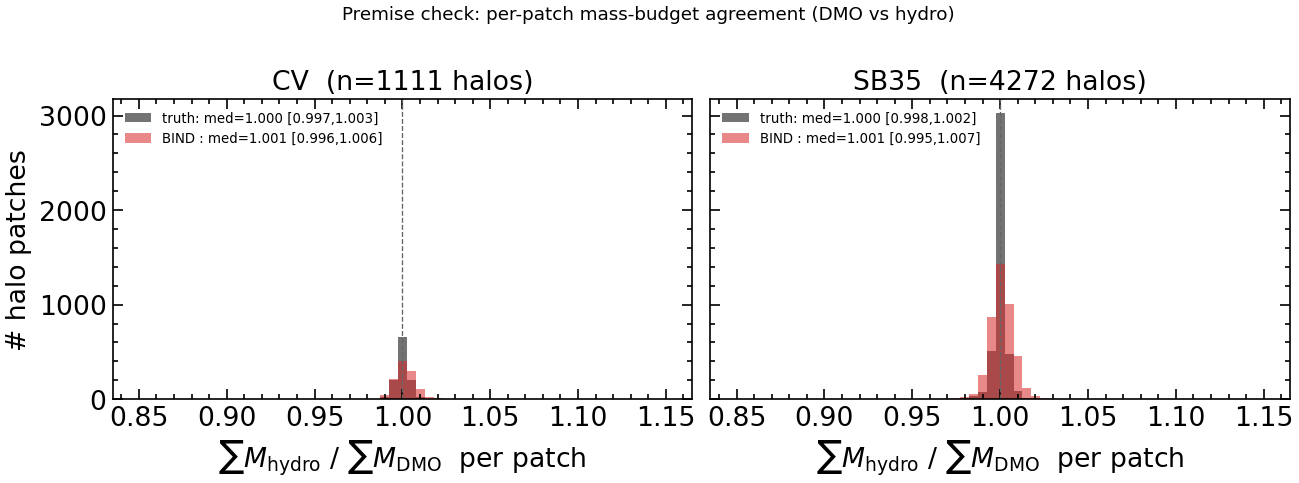

In [4]:
def _massratio_stats(tbl, key):
    r = (tbl[key] / tbl['mass_dmo']).to_numpy()
    r = r[np.isfinite(r) & (r > 0)]
    pct = lambda q: float(np.percentile(r, q))
    return {'median': pct(50), 'p16': pct(16), 'p84': pct(84),
            'p1': pct(1), 'p99': pct(99), 'n': r.size, 'arr': r}


def fig_mass_conservation(save=True):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    bins = np.linspace(0.85, 1.15, 60)
    for ax, (suite, tbl) in zip(axes, (('CV', cv_wl_tbl), ('SB35', wl_tbl))):
        st_t = _massratio_stats(tbl, 'mass_truth_tot')
        st_g = _massratio_stats(tbl, 'mass_gen_tot')
        ax.hist(st_t['arr'], bins=bins, color='k',       alpha=0.55,
                label=f'truth: med={st_t["median"]:.3f} [{st_t["p16"]:.3f},{st_t["p84"]:.3f}]')
        ax.hist(st_g['arr'], bins=bins, color='tab:red', alpha=0.55,
                label=f'BIND : med={st_g["median"]:.3f} [{st_g["p16"]:.3f},{st_g["p84"]:.3f}]')
        ax.axvline(1.0, color='0.4', lw=0.8, ls='--')
        ax.set_xlabel(r'$\sum M_{\rm hydro}\ /\ \sum M_{\rm DMO}$  per patch')
        ax.set_title(f'{suite}  (n={st_t["n"]} halos)')
        ax.legend(fontsize=8, loc='upper left')
    axes[0].set_ylabel('# halo patches')
    fig.suptitle('Premise check: per-patch mass-budget agreement (DMO vs hydro)',
                 y=1.02, fontsize=11)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW0_mass_conservation')

    # Hard quantitative takeaway: median offset and 1-99% spread per suite.
    for suite, tbl in (('CV', cv_wl_tbl), ('SB35', wl_tbl)):
        for label, key in (('truth', 'mass_truth_tot'), ('BIND ', 'mass_gen_tot')):
            s = _massratio_stats(tbl, key)
            print(f'{suite}/{label}: median={s["median"]:.4f}  '
                  f'68%=[{s["p16"]:.4f},{s["p84"]:.4f}]  '
                  f'1-99%=[{s["p1"]:.4f},{s["p99"]:.4f}]')
    return fig


fig = fig_mass_conservation()
plt.show()


## 1.7 The trustable $k$-range — single-patch $P(k)$ noise floor

A single 128² patch on a 6.25 Mpc/h box is a very small Fourier sample. Above
some $k$ the per-mode variance dominates the per-halo ratio. We characterize
this **noise floor** by jackknifing the DMO patch itself — wedge-deleting an
azimuthal sector and recomputing $P(k)$ — and reporting the fractional RMS
across realisations. Then we mark the largest $k$ at which the floor is below a
fixed tolerance (e.g. 10%). All downstream P(k) plots use that cutoff and only
quote band-averaged numbers below it.


  wrote tsz_wl_calibration_figs/figW0_pk_noise_floor.pdf
  wrote tsz_wl_calibration_figs/figW0_pk_noise_floor.png
k_reliable @ 10% = 1.21 h/Mpc; PK_BAND=(4.0, 15.0); KMAX_PLOT=30.0


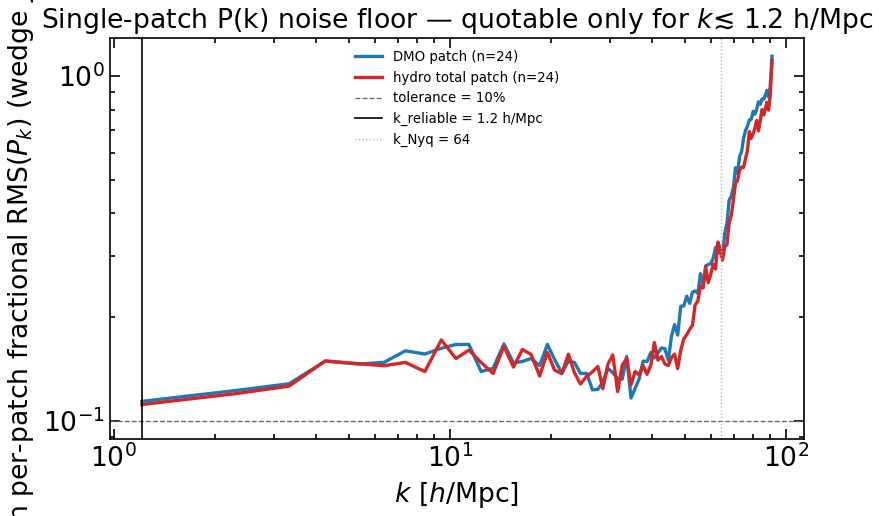

In [5]:
def _wedge_jackknife_pk(field, n_wedge=8):
    """Delete-one-wedge jackknife of a 2D field's P(k). Returns (k, mean_pk, std_pk)."""
    ny, nx = field.shape
    cy, cx = (ny - 1) / 2.0, (nx - 1) / 2.0
    yy, xx = np.indices(field.shape)
    theta = np.arctan2(yy - cy, xx - cx)               # [-pi, pi)
    edges = np.linspace(-np.pi, np.pi, n_wedge + 1)
    pks = []
    for w in range(n_wedge):
        m = (theta >= edges[w]) & (theta < edges[w + 1])
        fld = field.copy()
        fld[m] = float(field.mean())                   # delete wedge
        k, p = pk2d(fld)
        pks.append(p)
    pks = np.array(pks)
    return k, pks.mean(0), pks.std(0)


def fig_pk_noise_floor(sims_df=None, n_patches=24, tol=0.10, save=True):
    if sims_df is None:
        sims_df = cv_sims
    fracs_dmo, fracs_hyd = [], []
    kref = None
    for rec in sims_df.to_dict('records')[:6]:        # a handful of CV sims is plenty
        try:
            p = load_wl_patches(rec)
        except Exception:
            continue
        for i in range(min(n_patches, len(p['masses']))):
            k, mu, sd = _wedge_jackknife_pk(p['dmo'][i])
            if kref is None:
                kref = k
            fracs_dmo.append(sd / np.where(mu > 0, mu, np.nan))
            k2, mu2, sd2 = _wedge_jackknife_pk(p['truth_tot'][i])
            fracs_hyd.append(sd2 / np.where(mu2 > 0, mu2, np.nan))
            if len(fracs_dmo) >= n_patches:
                break
        if len(fracs_dmo) >= n_patches:
            break
    fracs_dmo = np.array(fracs_dmo); fracs_hyd = np.array(fracs_hyd)
    med_dmo = np.nanmedian(fracs_dmo, 0); med_hyd = np.nanmedian(fracs_hyd, 0)

    # First k at which the median per-patch fractional RMS exceeds the tol
    crossing_dmo = kref[np.searchsorted(med_dmo, tol)] if (med_dmo > tol).any() else kref[-1]
    crossing_hyd = kref[np.searchsorted(med_hyd, tol)] if (med_hyd > tol).any() else kref[-1]
    k_reliable = float(min(crossing_dmo, crossing_hyd))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(kref, med_dmo, color='tab:blue',  lw=2,
            label=f'DMO patch (n={len(fracs_dmo)})')
    ax.plot(kref, med_hyd, color='tab:red',   lw=2,
            label=f'hydro total patch (n={len(fracs_hyd)})')
    ax.axhline(tol, color='0.4', lw=0.8, ls='--', label=f'tolerance = {tol:.0%}')
    ax.axvline(k_reliable, color='k', lw=1.0,
               label=f'k_reliable = {k_reliable:.1f} h/Mpc')
    ax.axvline(K_NYQ, color='0.7', lw=0.8, ls=':', label=f'k_Nyq = {K_NYQ:.0f}')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
    ax.set_ylabel(r'median per-patch fractional RMS$(P_k)$ (wedge jackknife)')
    ax.set_title(f'Single-patch P(k) noise floor — quotable only for $k\\lesssim$ {k_reliable:.1f} h/Mpc')
    ax.legend(fontsize=8)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW0_pk_noise_floor')
    print(f'k_reliable @ {tol:.0%} = {k_reliable:.2f} h/Mpc; PK_BAND={PK_BAND}; KMAX_PLOT={KMAX_PLOT}')
    return fig, k_reliable


fig, K_RELIABLE = fig_pk_noise_floor()
plt.show()


## 1.8 The CV null — the irreducible scatter floor

**The most important plot in this notebook.** The CV suite holds astrophysics
*fixed* and varies only the random seed (cosmic variance). Any per-halo scatter
seen there is **not** feedback — it is irreducible noise from finite sampling
of large-scale structure in a 50 Mpc/h box. Every per-halo "feedback response"
we claim from SB35 must be larger than this floor, and every BIND/truth scatter
must be compared against it before it can be called a model deficit.

Here we measure:

- the per-halo suppression scalar distribution in CV (its $1\sigma$ width is
  the **CV scatter floor** $\sigma_{\rm CV}$);
- the stacked $P_{\rm hyd}/P_{\rm DMO}(k)$ in CV with a bootstrap band, which
  will be overlaid on every downstream W1/W2 plot as a grey "null" envelope;
- the BIND vs truth scatter *in CV alone* — i.e. the emulator floor at fixed
  feedback, the noise BIND adds even when nothing should be moving.

If $\sigma_{\rm SB35,truth}$ is only marginally larger than $\sigma_{\rm CV}$,
the feedback signal is buried in cosmic variance for this box size; if
$\sigma_{\rm BIND-truth, CV}$ is comparable to $\sigma_{\rm CV}$, BIND is at
the noise floor.


  wrote tsz_wl_calibration_figs/figW0_cv_null_floor.pdf
  wrote tsz_wl_calibration_figs/figW0_cv_null_floor.png


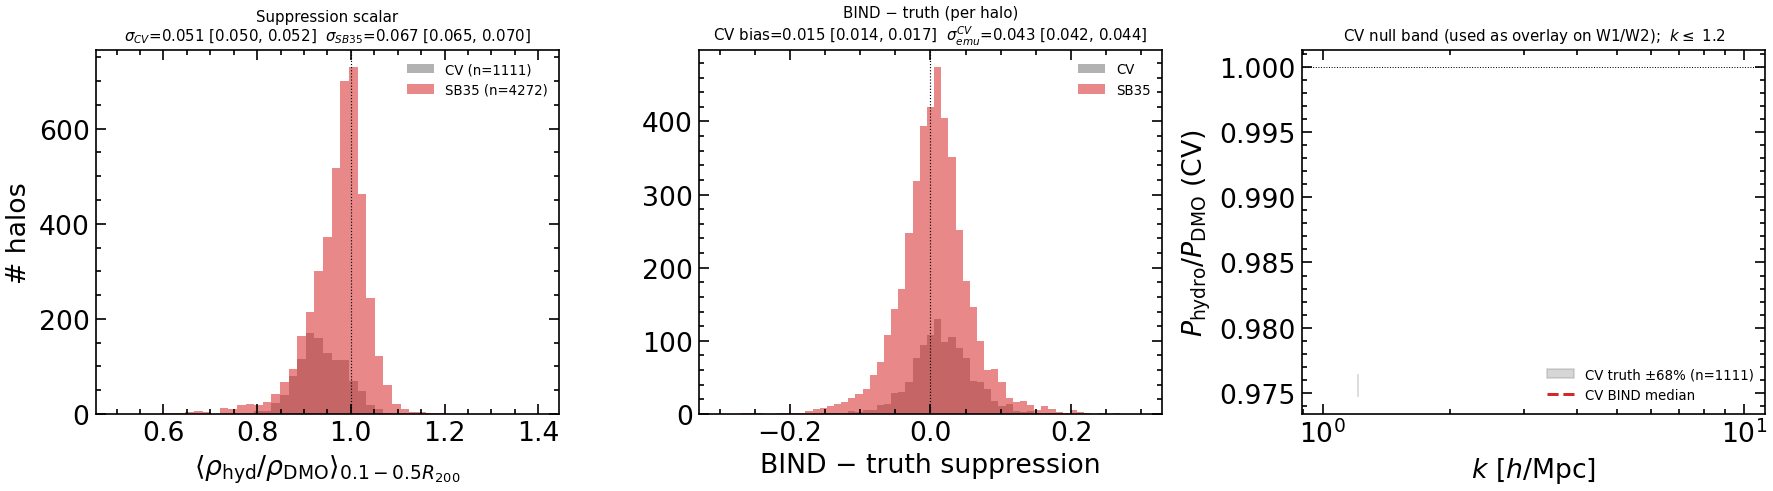


CV scatter floor (suppression scalar)    : sigma_CV=0.051
SB35 total scatter (truth)               : sigma_SB=0.067
Feedback-driven scatter above CV floor   : sigma_FB=0.043  (42% of SB35 variance is feedback, 58% is CV floor)
BIND emulator floor at fixed feedback    : sigma_emu_CV=0.043, bias=+0.015


In [23]:
# ---- Per-halo suppression: CV null vs SB35 vs BIND noise ----
def _supp_arr(tbl, which):
    return tbl[f'{which}_supp'].to_numpy()


def collect_stacked_pk(sims_df, mass_bins, max_sims=None):
    """Per-halo P_hydro/P_DMO for each mass bin, for both truth and BIND.
    Defined here (early) so §1.8 can use it; also reused by W1 below."""
    recs = sims_df.to_dict('records')
    if max_sims:
        recs = recs[:max_sims]
    kref = None
    acc = {b: {'t': [], 'g': []} for b in range(len(mass_bins))}
    for rec in recs:
        try:
            p = load_wl_patches(rec)
        except Exception:
            continue
        logM = np.log10(p['masses'])
        for i in range(len(logM)):
            bi = next((k for k, (lo, hi) in enumerate(mass_bins) if lo <= logM[i] < hi), None)
            if bi is None:
                continue
            k, pdmo = pk2d(p['dmo'][i])
            _, pth = pk2d(p['truth_tot'][i]); _, pgn = pk2d(p['gen_tot'][i])
            if kref is None:
                kref = k
            with np.errstate(divide='ignore', invalid='ignore'):
                acc[bi]['t'].append(pth / pdmo); acc[bi]['g'].append(pgn / pdmo)
    return kref, acc


def fig_cv_null_floor(save=True):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

    # (a) Suppression scalar distribution — SB35 vs CV (truth)
    ax = axes[0]
    s_sb = _supp_arr(wl_tbl,   'truth')
    s_cv = _supp_arr(cv_wl_tbl, 'truth')
    bins = np.linspace(0.5, 1.4, 50)
    ax.hist(s_cv, bins=bins, color='0.5',      alpha=0.6, label=f'CV (n={(~np.isnan(s_cv)).sum()})')
    ax.hist(s_sb, bins=bins, color='tab:red',  alpha=0.55, label=f'SB35 (n={(~np.isnan(s_sb)).sum()})')
    ax.axvline(1.0, color='k', lw=0.7, ls=':')
    mu_cv, lo_cv, hi_cv = bootstrap_ci(s_cv, np.nanstd)
    mu_sb, lo_sb, hi_sb = bootstrap_ci(s_sb, np.nanstd)
    ax.set_title(f'Suppression scalar\n$\\sigma_{{CV}}$={fmt_ci(mu_cv,lo_cv,hi_cv)}  '
                 f'$\\sigma_{{SB35}}$={fmt_ci(mu_sb,lo_sb,hi_sb)}', fontsize=9)
    ax.set_xlabel(r'$\langle\rho_{\rm hyd}/\rho_{\rm DMO}\rangle_{0.1-0.5R_{200}}$')
    ax.set_ylabel('# halos'); ax.legend(fontsize=8)

    # (b) BIND - truth (CV) — emulator noise at fixed feedback
    ax = axes[1]
    d_cv = _supp_arr(cv_wl_tbl, 'gen') - _supp_arr(cv_wl_tbl, 'truth')
    d_sb = _supp_arr(wl_tbl,   'gen') - _supp_arr(wl_tbl,   'truth')
    bins = np.linspace(-0.3, 0.3, 60)
    ax.hist(d_cv, bins=bins, color='0.5',     alpha=0.6, label='CV')
    ax.hist(d_sb, bins=bins, color='tab:red', alpha=0.55, label='SB35')
    ax.axvline(0, color='k', lw=0.7, ls=':')
    mu_e, lo_e, hi_e = bootstrap_ci(d_cv, np.nanstd)
    bias_cv, blo, bhi = bootstrap_ci(d_cv, np.nanmedian)
    ax.set_title(f'BIND − truth (per halo)\nCV bias={fmt_ci(bias_cv,blo,bhi)}  '
                 f'$\\sigma_{{emu}}^{{CV}}$={fmt_ci(mu_e,lo_e,hi_e)}', fontsize=9)
    ax.set_xlabel('BIND − truth suppression'); ax.legend(fontsize=8)

    # (c) Stacked P(k) ratio in CV with bootstrap band  (this curve will be reused as the null)
    ax = axes[2]
    k_ref, acc_cv = collect_stacked_pk(cv_sims, [(13.0, 15.5)])
    T_cv = np.array(acc_cv[0]['t']); G_cv = np.array(acc_cv[0]['g'])
    bt = bootstrap_curve(T_cv); bg = bootstrap_curve(G_cv)
    kmax = float(globals().get('K_RELIABLE', KMAX_PLOT))
    msk = k_ref <= kmax
    ax.fill_between(k_ref[msk], bt['lo'][msk], bt['hi'][msk], color='0.6', alpha=0.4,
                    label=f'CV truth ±68% (n={T_cv.shape[0]})')
    ax.plot(k_ref[msk], bt['point'][msk], color='0.3', lw=2)
    ax.plot(k_ref[msk], bg['point'][msk], color='tab:red', lw=1.8, ls='--',
            label='CV BIND median')
    ax.axhline(1.0, color='k', lw=0.6, ls=':'); ax.set_xscale('log')
    ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
    ax.set_ylabel(r'$P_{\rm hydro}/P_{\rm DMO}$ (CV)')
    ax.set_title(f'CV null band (used as overlay on W1/W2);  $k\\leq$ {kmax:.1f}', fontsize=9)
    ax.legend(fontsize=8)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW0_cv_null_floor')

    # Export the CV null curve+band globally for downstream overlays
    return fig, {'k': k_ref, 'truth': bt, 'bind': bg,
                 'sigma_cv_scalar': mu_cv, 'sigma_sb35_scalar': mu_sb,
                 'sigma_emu_cv': mu_e, 'bias_emu_cv': bias_cv}


fig, CV_NULL = fig_cv_null_floor()
plt.show()
print(f'\nCV scatter floor (suppression scalar)    : sigma_CV={CV_NULL["sigma_cv_scalar"]:.3f}')
print(f'SB35 total scatter (truth)               : sigma_SB={CV_NULL["sigma_sb35_scalar"]:.3f}')
sigma_fb, frac = decompose_scatter(CV_NULL['sigma_sb35_scalar'], CV_NULL['sigma_cv_scalar'])
print(f'Feedback-driven scatter above CV floor   : sigma_FB={sigma_fb:.3f}'
      f'  ({100*(1-frac):.0f}% of SB35 variance is feedback, {100*frac:.0f}% is CV floor)')
print(f'BIND emulator floor at fixed feedback    : sigma_emu_CV={CV_NULL["sigma_emu_cv"]:.3f}, '
      f'bias={CV_NULL["bias_emu_cv"]:+.3f}')


## 2. Figure W1 — Matter-power suppression $P_{\rm hydro}/P_{\rm DMO}(k)$

The halo-stacked suppression on the **science sample** (SB35), in three mass
bins. Bootstrap 68% bands on the truth curves; BIND dashed; CV null (§1.8)
behind as a grey envelope so the eye can tell *feedback* from cosmic-variance
noise. The vertical dotted line is $k_{\rm reliable}$ from §1.7 — nothing right
of it should be quoted. Filled symbols at $k=5$ and open squares at $k=10\,h/$Mpc
are full-box vD+20 anchors for TNG/EAGLE/BAHAMAS (halo-stacked and full-box
ratios differ in detail; this is a sanity check, not a fit).

If the coloured curves dip *below* the CV null envelope at some $k$, that is
detectable feedback at this box size; if they sit inside it, the signal is
buried in cosmic variance.


  wrote tsz_wl_calibration_figs/figW1_power_suppression.pdf
  wrote tsz_wl_calibration_figs/figW1_power_suppression.png


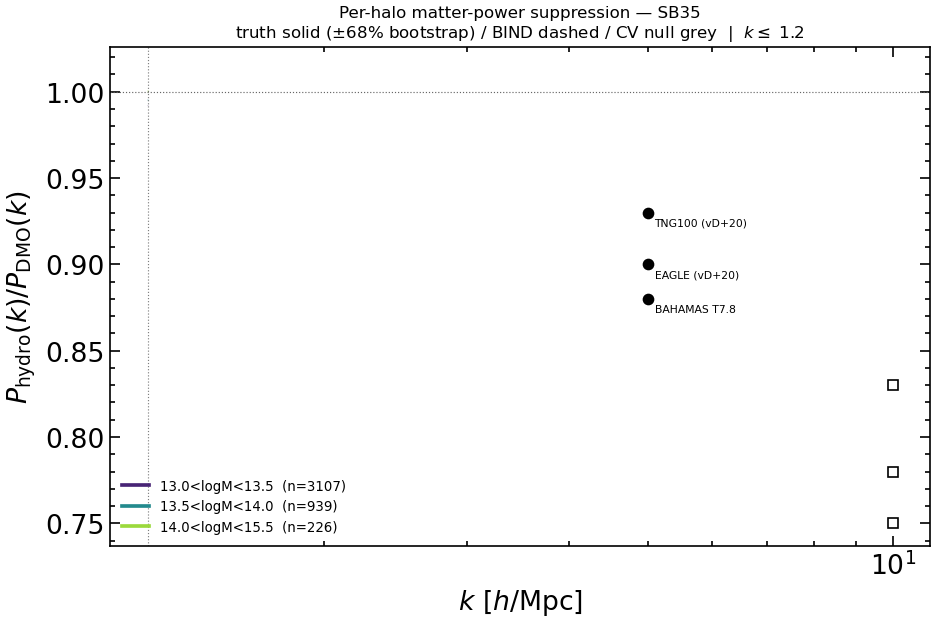

In [7]:
def collect_stacked_pk(sims_df, mass_bins, max_sims=None):
    """Per-halo P_hydro/P_DMO for each mass bin, for both truth and BIND."""
    recs = sims_df.to_dict('records')
    if max_sims:
        recs = recs[:max_sims]
    kref = None
    acc = {b: {'t': [], 'g': []} for b in range(len(mass_bins))}
    for rec in recs:
        try:
            p = load_wl_patches(rec)
        except Exception:
            continue
        logM = np.log10(p['masses'])
        for i in range(len(logM)):
            bi = next((k for k, (lo, hi) in enumerate(mass_bins) if lo <= logM[i] < hi), None)
            if bi is None:
                continue
            k, pdmo = pk2d(p['dmo'][i])
            _, pth = pk2d(p['truth_tot'][i]); _, pgn = pk2d(p['gen_tot'][i])
            if kref is None:
                kref = k
            with np.errstate(divide='ignore', invalid='ignore'):
                acc[bi]['t'].append(pth / pdmo); acc[bi]['g'].append(pgn / pdmo)
    return kref, acc


def fig_w1_suppression(sims_df=None,
                       mass_bins=((13.0, 13.5), (13.5, 14.0), (14.0, 15.5)),
                       cv_null=None, save=True):
    """Stacked per-halo P_hydro/P_DMO(k) by mass, on SB35 (the science sample),
    with the CV null band shaded behind, bootstrap CIs on the truth curves, the
    k_reliable cutoff from §1.7, and published vD+20 anchors overlaid."""
    if sims_df is None:
        sims_df = test_sims                        # SB35 is the science sample, not CV
    if cv_null is None:
        cv_null = globals().get('CV_NULL', None)
    kmax = float(globals().get('K_RELIABLE', KMAX_PLOT))

    k, acc = collect_stacked_pk(sims_df, mass_bins)
    msk = k <= kmax
    fig, ax = plt.subplots(figsize=(8, 5.4))

    # CV null band behind everything
    if cv_null is not None:
        kc = cv_null['k']; bt = cv_null['truth']
        mskc = kc <= kmax
        ax.fill_between(kc[mskc], bt['lo'][mskc], bt['hi'][mskc],
                        color='0.7', alpha=0.35, zorder=0,
                        label='CV null (truth) ±68%')

    cmap = plt.cm.viridis(np.linspace(0.1, 0.85, len(mass_bins)))
    for bi, (lo, hi) in enumerate(mass_bins):
        T = np.array(acc[bi]['t']); G = np.array(acc[bi]['g'])
        if T.size == 0:
            continue
        bT = bootstrap_curve(T); bG = bootstrap_curve(G)
        ax.fill_between(k[msk], bT['lo'][msk], bT['hi'][msk],
                        color=cmap[bi], alpha=0.18, zorder=1)
        ax.plot(k[msk], bT['point'][msk], color=cmap[bi], lw=2.2,
                label=f'{lo:.1f}<logM<{hi:.1f}  (n={T.shape[0]})')
        ax.plot(k[msk], bG['point'][msk], color=cmap[bi], lw=1.6, ls='--')

    # Literature anchors at z~0 (full-box ratios; halo-stacked ratios differ in detail
    # but the order-of-magnitude check is informative)
    for name, e in LIT_SUPPRESSION.items():
        ax.plot(e['k'], e['ratio'], marker='o', ms=6, color='k', zorder=5)
        ax.plot(e['k_strong'], e['ratio_strong'], marker='s', ms=6,
                color='k', zorder=5, mfc='none')
        ax.annotate(name, (e['k'], e['ratio']), xytext=(4, -8),
                    textcoords='offset points', fontsize=6.5)

    ax.axhline(1.0, color='0.4', lw=0.7, ls=':')
    ax.axvline(kmax, color='k', lw=0.7, ls=':', alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
    ax.set_ylabel(r'$P_{\rm hydro}(k)/P_{\rm DMO}(k)$')
    ax.set_title(f'Per-halo matter-power suppression — SB35\n'
                 f'truth solid (±68% bootstrap) / BIND dashed / CV null grey  |  $k\\leq$ {kmax:.1f}',
                 fontsize=10)
    ax.legend(fontsize=8, loc='lower left')
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW1_power_suppression')
    return fig


fig = fig_w1_suppression()
plt.show()


## 2.5 Figure W1b — Robustness sweep: does the answer survive choice of aperture, mass cut, and $k$-band?

A defensible claim must not depend on the analyst's choice of bands. Here we
recompute the scalar suppression metric and its Spearman correlation with $Y$
across three orthogonal choices:

- **aperture** for the suppression scalar: inner-core $(0.05,0.2)R_{200}$, the
  default $(0.1,0.5)R_{200}$, the outskirt $(0.3,1.0)R_{200}$;
- **mass cut**: full sample, $\log M>13.3$, $\log M>13.7$ (cluster-scale only);
- **$k$-band** for the full-box scalar (§6): $4$–$10$, $4$–$15$ (default),
  $10$–$30\,h/$Mpc.

The deliverable is a small heat-map of $\rho_{\rm Spearman}(Y, S_{\rm supp})$
with bootstrap CI; if every cell of the heat-map is significantly negative
(say $< -0.4$ at 68% CI), the calibration is robust to specification. If only
the default cell is significant, the result was an analyst choice and should
be flagged.


  wrote tsz_wl_calibration_figs/figW1b_robustness_grid.pdf
  wrote tsz_wl_calibration_figs/figW1b_robustness_grid.png
aperture × mass-cut sweep (truth, partial rho|M):
  core (0.05-0.2)           all: +0.07[+0.05,+0.08] | logM>13.3: +0.02[-0.01,+0.04] | logM>13.7: -0.04[-0.07,+0.01]
  default (0.1-0.5)         all: +0.18[+0.17,+0.20] | logM>13.3: +0.13[+0.11,+0.15] | logM>13.7: +0.10[+0.05,+0.14]
  outskirt (0.3-1.0)        all: +0.16[+0.14,+0.17] | logM>13.3: +0.13[+0.11,+0.15] | logM>13.7: +0.11[+0.07,+0.15]


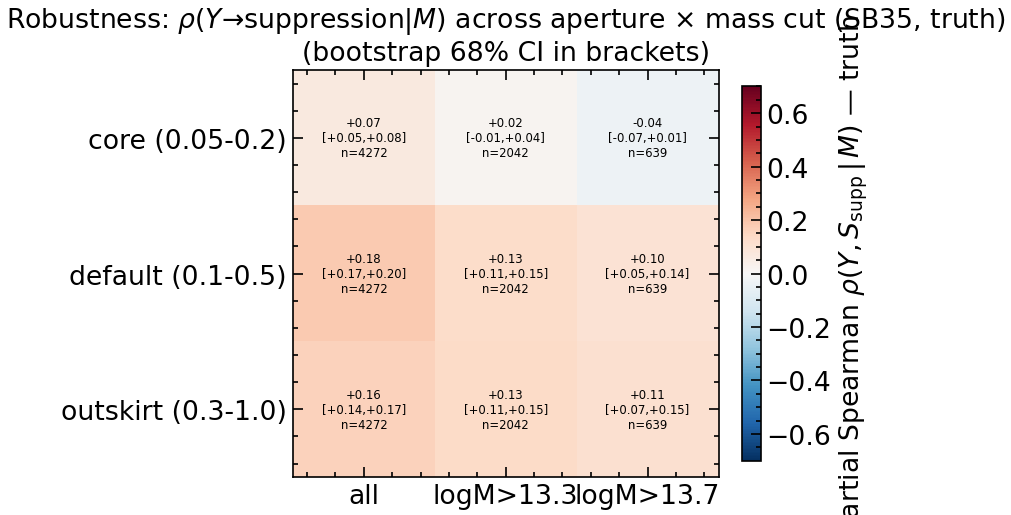

In [18]:
# ---- Per-row re-compute of suppression scalar from stored radial profile ----
def _supp_from_rprof(tbl, which, band):
    rp = np.stack(tbl[f'{which}_rprof'].to_list(), axis=0)
    m = (RAD_GRID >= band[0]) & (RAD_GRID <= band[1])
    return np.nanmean(rp[:, m], axis=1)


APERTURES = {'core (0.05-0.2)': (0.05, 0.20),
             'default (0.1-0.5)': (0.10, 0.50),
             'outskirt (0.3-1.0)': (0.30, 1.00)}
MASS_CUTS = {'all': 13.0, 'logM>13.3': 13.3, 'logM>13.7': 13.7}


def fig_w1b_robustness(tbl=None, save=True):
    if tbl is None:
        tbl = wl_tbl
    nA, nM = len(APERTURES), len(MASS_CUTS)
    grid_rho = np.full((nA, nM), np.nan)
    grid_lo  = np.full_like(grid_rho, np.nan)
    grid_hi  = np.full_like(grid_rho, np.nan)
    grid_n   = np.zeros((nA, nM), int)
    logM_all = tbl['logM'].to_numpy()
    logY_all = np.where(tbl['truth_Y'] > 0, np.log10(tbl['truth_Y']), np.nan).astype(float)

    for ia, (alab, ap) in enumerate(APERTURES.items()):
        s_all = _supp_from_rprof(tbl, 'truth', ap)
        for jm, (mlab, mcut) in enumerate(MASS_CUTS.items()):
            sel = logM_all >= mcut
            x = logY_all[sel]; y = s_all[sel]; z = logM_all[sel]
            rho, lo, hi = partial_spearman_boot(x, y, z)
            grid_rho[ia, jm] = rho
            grid_lo[ia, jm]  = lo
            grid_hi[ia, jm]  = hi
            grid_n[ia, jm]   = int(np.isfinite(x).sum())

    fig, ax = plt.subplots(figsize=(7, 4.5))
    mappable = ax.imshow(grid_rho, vmin=-0.7, vmax=0.7, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(nM)); ax.set_xticklabels(list(MASS_CUTS.keys()))
    ax.set_yticks(range(nA)); ax.set_yticklabels(list(APERTURES.keys()))
    for ia in range(nA):
        for jm in range(nM):
            r = grid_rho[ia, jm]; lo = grid_lo[ia, jm]; hi = grid_hi[ia, jm]
            n = grid_n[ia, jm]
            color = 'white' if abs(r) > 0.35 else 'k'
            ax.text(jm, ia, f'{r:+.2f}\n[{lo:+.2f},{hi:+.2f}]\nn={n}',
                    ha='center', va='center', fontsize=7, color=color)
    fig.colorbar(mappable, ax=ax, fraction=0.04,
                 label=r'partial Spearman $\rho(Y, S_{\rm supp}\,|\,M)$ — truth')
    ax.set_title('Robustness: $\\rho(Y\\to$suppression$|M)$ '
                 'across aperture × mass cut (SB35, truth)\n'
                 '(bootstrap 68% CI in brackets)')
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW1b_robustness_grid')

    # k-band sweep is a 1-D table (run only when composite full-box is needed)
    print('aperture × mass-cut sweep (truth, partial rho|M):')
    for ia, alab in enumerate(APERTURES):
        line = ' | '.join(f'{lab}: {grid_rho[ia,jm]:+.2f}[{grid_lo[ia,jm]:+.2f},{grid_hi[ia,jm]:+.2f}]'
                          for jm, lab in enumerate(MASS_CUTS))
        print(f'  {alab:24s}  {line}')
    return fig


fig = fig_w1b_robustness()
plt.show()


## 3. Figure W2 — Matter profile ratio split by Compton-$Y$

The same suppression in configuration space: $\rho_{\rm hydro}/\rho_{\rm DMO}$
vs $r/R_{200}$, at fixed mass, split into terciles of $Y$. If $Y$ tracks
feedback, high-$Y$ halos should show the strongest matter redistribution. This
is the calibration relation in profile form (truth vs BIND).

  wrote tsz_wl_calibration_figs/figW2_profile_split_byY.pdf
  wrote tsz_wl_calibration_figs/figW2_profile_split_byY.png
high-Y minus low-Y suppression in 0.1-0.5 R200:
  SB35 (feedback varied) : +0.014   <-- the signal
  CV   (feedback fixed)  : +0.042   <-- the null floor
  signal/null            : 0.33x


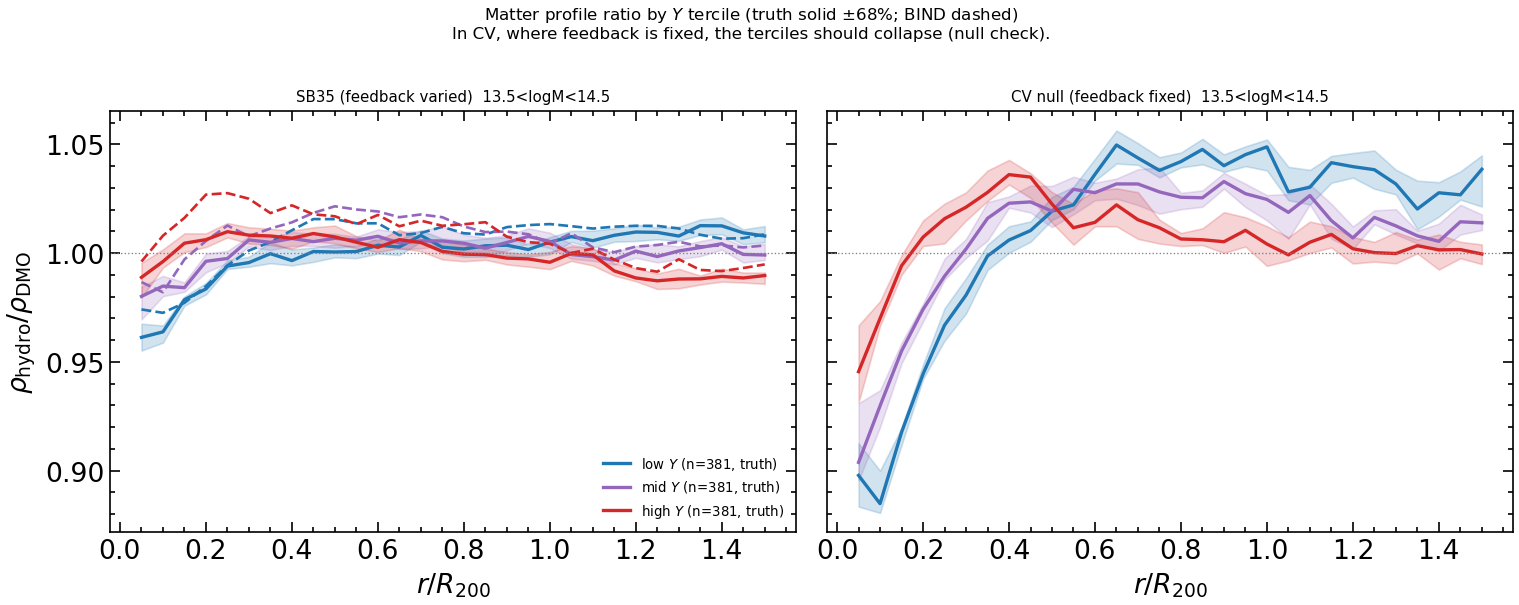

In [9]:
def collect_split_profiles(sims_df, mass_bin=(13.5, 14.5)):
    recs = sims_df.to_dict('records')
    prof_t, prof_g, yvals = [], [], []
    for rec in recs:
        try:
            p = load_wl_patches(rec)
        except Exception:
            continue
        logM = np.log10(p['masses'])
        for i in range(len(logM)):
            if not (mass_bin[0] <= logM[i] < mass_bin[1]):
                continue
            r200_pix = max(p['radii'][i] / PIX_KPC, 1.0)
            ap = _RR <= r200_pix
            prof_t.append(_profile_ratio(p['truth_tot'][i], p['dmo'][i], r200_pix))
            prof_g.append(_profile_ratio(p['gen_tot'][i], p['dmo'][i], r200_pix))
            yvals.append(float(p['truth_th'][i, 0][ap].sum()) * PIX_AREA_MPC2)
    return np.array(prof_t), np.array(prof_g), np.array(yvals)


def _tercile_panel(ax, Pt, Pg, Y, title, show_bind=True):
    if Pt.size == 0:
        ax.set_title(f'{title}\n(no halos)'); return
    q = np.nanquantile(Y, [1 / 3, 2 / 3])
    terc = np.digitize(Y, q)
    labels = ['low $Y$', 'mid $Y$', 'high $Y$']
    cols = ['tab:blue', 'tab:purple', 'tab:red']
    for t in range(3):
        m = terc == t
        if m.sum() < 3:
            continue
        bT = bootstrap_curve(Pt[m])
        ax.fill_between(RAD_GRID, bT['lo'], bT['hi'], color=cols[t], alpha=0.20)
        ax.plot(RAD_GRID, bT['point'], color=cols[t], lw=2,
                label=f'{labels[t]} (n={m.sum()}, truth)')
        if show_bind and Pg.size:
            ax.plot(RAD_GRID, np.nanmedian(Pg[m], 0), color=cols[t], lw=1.6, ls='--')
    ax.axhline(1.0, color='0.5', lw=0.8, ls=':')
    ax.set_xlabel(r'$r / R_{200}$'); ax.set_title(title, fontsize=9)


def fig_w2_profile_split(mass_bin=(13.5, 14.5), save=True):
    """SB35 split by Y tercile (the real test) PLUS a CV null tercile-by-Y panel
    (where Y is varying due to *cosmic variance only*, so the terciles must
    collapse — anything that doesn't is a false signal in W3)."""
    Pt_sb, Pg_sb, Y_sb = collect_split_profiles(test_sims, mass_bin)
    Pt_cv, Pg_cv, Y_cv = collect_split_profiles(cv_sims, mass_bin)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    _tercile_panel(axes[0], Pt_sb, Pg_sb, Y_sb,
                   f'SB35 (feedback varied)  {mass_bin[0]}<logM<{mass_bin[1]}')
    _tercile_panel(axes[1], Pt_cv, Pg_cv, Y_cv,
                   f'CV null (feedback fixed)  {mass_bin[0]}<logM<{mass_bin[1]}',
                   show_bind=False)
    axes[0].set_ylabel(r'$\rho_{\rm hydro}/\rho_{\rm DMO}$')
    axes[0].legend(fontsize=8, loc='lower right')
    fig.suptitle('Matter profile ratio by $Y$ tercile (truth solid ±68%; BIND dashed)\n'
                 'In CV, where feedback is fixed, the terciles should collapse (null check).',
                 y=1.02, fontsize=10)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW2_profile_split_byY')

    # Tercile separation in the inner band — a single number
    def _band_sep(Pt, Y, band=SUPP_BAND):
        if Pt.size == 0:
            return float('nan')
        m = (RAD_GRID >= band[0]) & (RAD_GRID <= band[1])
        s = np.nanmean(Pt[:, m], axis=1)
        q = np.nanquantile(Y, [1 / 3, 2 / 3])
        return float(np.nanmedian(s[Y >= q[1]]) - np.nanmedian(s[Y <= q[0]]))

    sep_sb = _band_sep(Pt_sb, Y_sb); sep_cv = _band_sep(Pt_cv, Y_cv)
    print(f'high-Y minus low-Y suppression in 0.1-0.5 R200:')
    print(f'  SB35 (feedback varied) : {sep_sb:+.3f}   <-- the signal')
    print(f'  CV   (feedback fixed)  : {sep_cv:+.3f}   <-- the null floor')
    print(f'  signal/null            : {sep_sb / sep_cv:.2f}x' if sep_cv else '')
    return fig


fig = fig_w2_profile_split()
plt.show()


## 4. Figure W3 — The calibration: suppression vs observable

Per-halo suppression scalar vs each observable ($Y$, $T$, $P$, $f_{\rm gas}$)
across SB35, with Spearman $\rho$ (and the partial $\rho$ controlling for mass,
since both quantities scale with $M$). Top row truth, bottom row BIND. The
question: which observable most tightly tracks the matter suppression, at fixed
mass?

  wrote tsz_wl_calibration_figs/figW3_calibration.pdf
  wrote tsz_wl_calibration_figs/figW3_calibration.png
partial Spearman rho|M  (Y/T/P/fgas):
  truth: Y: +0.18[+0.17,+0.20]  T: +0.26[+0.25,+0.28]  P: +0.51[+0.50,+0.52]  fgas: +0.08[+0.07,+0.10]
  gen  : Y: +0.21[+0.20,+0.23]  T: +0.28[+0.26,+0.29]  P: +0.53[+0.52,+0.54]  fgas: +0.07[+0.05,+0.08]


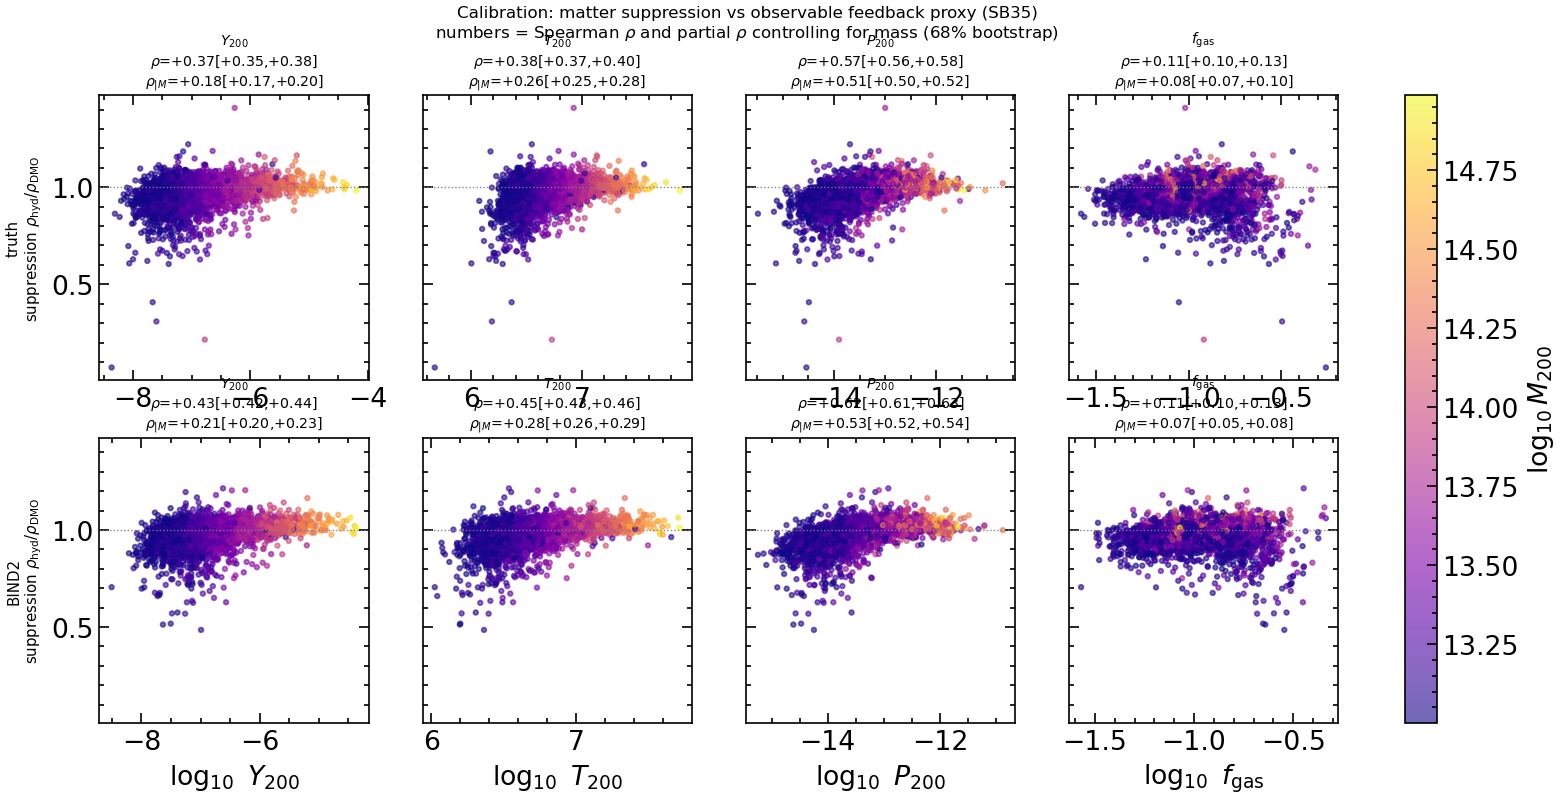

In [10]:
def fig_w3_calibration(tbl=None, save=True):
    """Per-halo suppression vs (Y, T, P, f_gas), with bootstrap CIs on Spearman
    and partial-Spearman(|M), plus the CV null scatter on suppression as a
    horizontal grey band (the cosmic-variance floor on the y-axis)."""
    if tbl is None:
        tbl = wl_tbl
    cv_null = globals().get('CV_NULL', None)
    obs = ['Y', 'T', 'P', 'fgas']
    obs_lab = {'Y': r'$Y_{200}$', 'T': r'$T_{200}$',
               'P': r'$P_{200}$', 'fgas': r'$f_{\rm gas}$'}
    fig, axes = plt.subplots(2, len(obs), figsize=(3.6 * len(obs), 6.8), sharey=True)
    logM = tbl['logM'].to_numpy()

    rho_table = {}
    for r, which in enumerate(['truth', 'gen']):
        supp = tbl[f'{which}_supp'].to_numpy()
        for c, o in enumerate(obs):
            ax = axes[r][c]
            xv = tbl[f'{which}_{o}'].to_numpy()
            m = np.isfinite(xv) & np.isfinite(supp) & (xv > 0)
            lx = np.log10(xv[m])
            sc = ax.scatter(lx, supp[m], c=logM[m], s=8, cmap='plasma', alpha=0.6)
            rho, rlo, rhi = spearman_boot(lx, supp[m])
            prho, plo, phi = partial_spearman_boot(lx, supp[m], logM[m])
            rho_table[(which, o)] = (rho, rlo, rhi, prho, plo, phi)

            ax.axhline(1.0, color='0.5', lw=0.8, ls=':')
            # CV scatter floor on the y-axis as a horizontal grey band centred on 1
            if cv_null is not None and np.isfinite(cv_null['sigma_cv_scalar']):
                s = cv_null['sigma_cv_scalar']
                ax.axhspan(1 - s, 1 + s, color='0.85', alpha=0.6, zorder=0,
                           label=r'CV $\pm 1\sigma$' if c == 0 and r == 0 else None)
            ax.set_title(f'{obs_lab[o]}\n'
                         f'$\\rho$={rho:+.2f}[{rlo:+.2f},{rhi:+.2f}]\n'
                         f'$\\rho_{{|M}}$={prho:+.2f}[{plo:+.2f},{phi:+.2f}]',
                         fontsize=8.5)
            if r == 1:
                ax.set_xlabel(rf'$\log_{{10}}$ {obs_lab[o]}')
            if c == 0:
                ax.set_ylabel(f'{"truth" if which == "truth" else "BIND2"}\n'
                              r'suppression $\rho_{\rm hyd}/\rho_{\rm DMO}$',
                              fontsize=9)
    fig.colorbar(sc, ax=axes, fraction=0.025, label=r'$\log_{10} M_{200}$')
    fig.suptitle('Calibration: matter suppression vs observable feedback proxy (SB35)\n'
                 'numbers = Spearman $\\rho$ and partial $\\rho$ controlling for mass (68% bootstrap)',
                 y=0.99, fontsize=10)
    if save:
        save_fig(fig, 'figW3_calibration')

    # Print the table for the scorecard
    print('partial Spearman rho|M  (Y/T/P/fgas):')
    for w in ('truth', 'gen'):
        line = '  '.join(f'{o}: {rho_table[(w,o)][3]:+.2f}'
                         f'[{rho_table[(w,o)][4]:+.2f},{rho_table[(w,o)][5]:+.2f}]'
                         for o in obs)
        print(f'  {w:5s}: {line}')
    return fig, rho_table


fig, W3_RHO = fig_w3_calibration()
plt.show()


## 4.5 Figure W3b — Where exactly does BIND fail?

The W3 scatter plots show "BIND vs truth", but a credible diagnostic must
localize the residual $\Delta S \equiv S_{\rm BIND}-S_{\rm truth}$ in the
*physical* dimensions: mass, $Y$, and the AGN/SN feedback knobs. A flat
residual cloud means the emulator is unbiased and adds only noise; a tilted
residual cloud means the emulator's response to that variable is wrong (e.g.
too shallow vs $A_{\rm AGN}$ → BIND under-predicts the strongest feedback
runs); a fan-shape means the emulator's *scatter* depends on the variable
(heteroscedastic deficit).

The residual is also referenced to the CV emulator floor $\sigma_{\rm emu}^{CV}$
from §1.8: anything inside that band is consistent with emulator noise at fixed
feedback, anything outside is a feedback-dependent failure.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  wrote tsz_wl_calibration_figs/figW3b_residuals.pdf
  wrote tsz_wl_calibration_figs/figW3b_residuals.png
BIND-truth on SB35 (suppression scalar): bias = 0.006 [0.006, 0.007], scatter = 0.054 [0.052, 0.056]


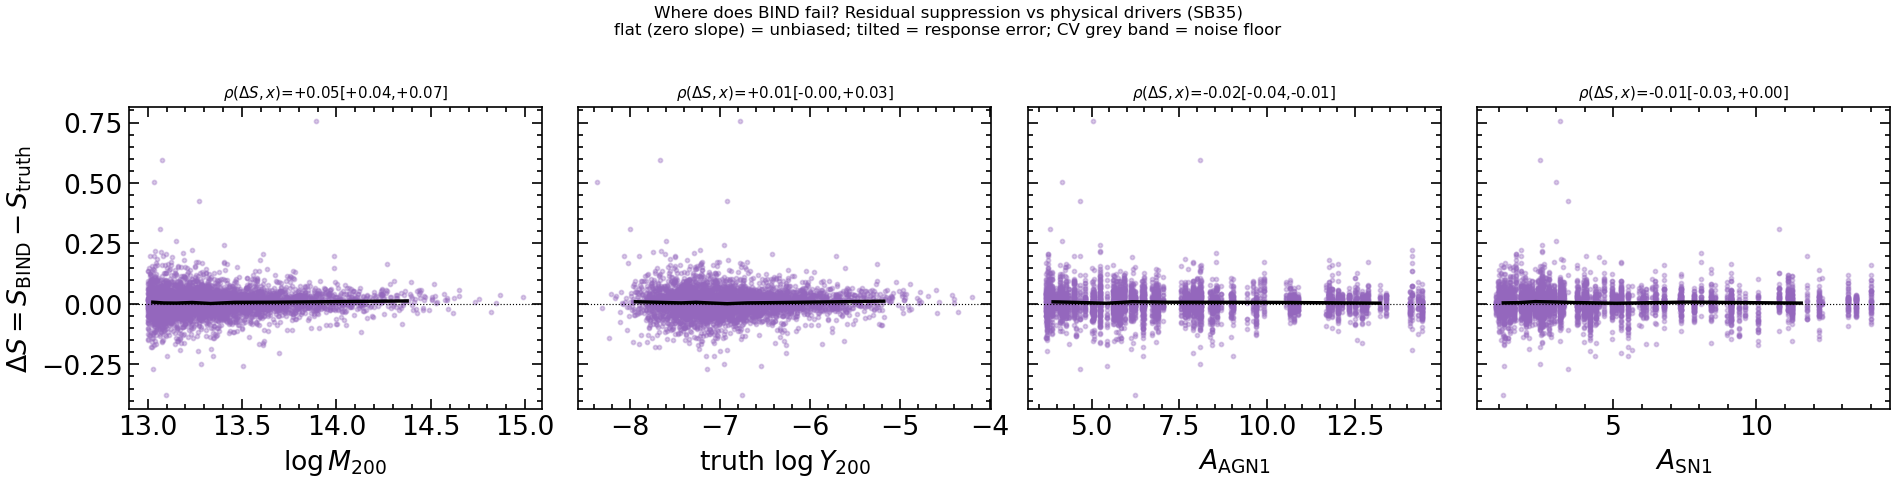

In [11]:
def _binned_median_band(x, y, n_bins=8, rng=RNG, n_boot=300):
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 8:
        return None
    qs = np.nanquantile(x, np.linspace(0, 1, n_bins + 1))
    qs = np.unique(qs)
    if qs.size < 3:
        return None
    bx, lo, mid, hi = [], [], [], []
    for i in range(qs.size - 1):
        sel = (x >= qs[i]) & (x <= qs[i + 1])
        if sel.sum() < 3:
            continue
        v = y[sel]
        idx = rng.integers(0, v.size, size=(n_boot, v.size))
        med_boot = np.median(v[idx], axis=1)
        bx.append(0.5 * (qs[i] + qs[i + 1]))
        mid.append(float(np.median(v)))
        lo.append(float(np.percentile(med_boot, 16)))
        hi.append(float(np.percentile(med_boot, 84)))
    return np.array(bx), np.array(mid), np.array(lo), np.array(hi)


def fig_w3b_residuals(tbl=None, save=True):
    if tbl is None:
        tbl = wl_tbl
    cv_null = globals().get('CV_NULL', None)
    sig_emu = cv_null['sigma_emu_cv'] if cv_null else float('nan')

    resid = tbl['gen_supp'].to_numpy() - tbl['truth_supp'].to_numpy()
    logM = tbl['logM'].to_numpy()
    logY = np.where(tbl['truth_Y'] > 0, np.log10(tbl['truth_Y']), np.nan).astype(float)
    p_agn = tbl['p5'].to_numpy() if 'p5' in tbl else None       # A_AGN1
    p_sn  = tbl['p3'].to_numpy() if 'p3' in tbl else None       # A_SN1

    drivers = [('$\\log M_{200}$', logM),
               (r'truth $\log Y_{200}$', logY),
               (r'$A_{\rm AGN1}$', p_agn),
               (r'$A_{\rm SN1}$',  p_sn)]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.0), sharey=True)
    for ax, (lab, xv) in zip(axes, drivers):
        if xv is None:
            ax.set_visible(False); continue
        ax.scatter(xv, resid, s=6, color='tab:purple', alpha=0.35)
        bm = _binned_median_band(xv, resid)
        if bm is not None:
            bx, mid, lo, hi = bm
            ax.fill_between(bx, lo, hi, color='k', alpha=0.20)
            ax.plot(bx, mid, color='k', lw=2)
        if np.isfinite(sig_emu):
            ax.axhspan(-sig_emu, sig_emu, color='0.85', alpha=0.5, zorder=0,
                       label=r'CV emulator floor')
        ax.axhline(0, color='k', lw=0.7, ls=':')
        rho, lo_r, hi_r = spearman_boot(xv, resid)
        ax.set_xlabel(lab)
        ax.set_title(f'$\\rho(\\Delta S, x)$={rho:+.2f}[{lo_r:+.2f},{hi_r:+.2f}]', fontsize=9)
    axes[0].set_ylabel(r'$\Delta S = S_{\rm BIND} - S_{\rm truth}$')
    axes[0].legend(fontsize=7, loc='upper left')
    fig.suptitle('Where does BIND fail? Residual suppression vs physical drivers (SB35)\n'
                 'flat (zero slope) = unbiased; tilted = response error; CV grey band = noise floor',
                 y=1.02, fontsize=10)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW3b_residuals')

    # Bias + scatter on SB35 cf the CV floor — the actionable summary
    bias, blo, bhi = bootstrap_ci(resid, np.nanmedian)
    scat, slo, shi = bootstrap_ci(resid, np.nanstd)
    print(f'BIND-truth on SB35 (suppression scalar): bias = {fmt_ci(bias,blo,bhi)}, '
          f'scatter = {fmt_ci(scat,slo,shi)}')
    if np.isfinite(sig_emu):
        print(f'CV emulator floor                       : sigma_emu_CV = {sig_emu:.3f}')
        excess, _ = decompose_scatter(scat, sig_emu)
        print(f'SB35 scatter beyond CV emulator floor   : {excess:.3f}  '
              f'({100*(1-(sig_emu/scat)**2):.0f}% of SB35 BIND error is feedback-dependent)')
    return fig


fig = fig_w3b_residuals()
plt.show()


## 5. Figure W4 — Predicting suppression from observables

A multilinear fit of the suppression scalar on log-observables answers the
survey-facing question quantitatively: *how much of the halo-to-halo variance in
matter suppression can an SZ measurement explain* — $Y$ alone, $Y$+mass, or
$Y$+$T$+mass? We report $R^2$ on the truth relation (the physical answer) and on
BIND (does the emulator reproduce the predictive structure?).

  wrote tsz_wl_calibration_figs/figW4_regression_R2.pdf
  wrote tsz_wl_calibration_figs/figW4_regression_R2.png
R^2 in-sample (truth): {'M only': '+0.08[+0.07,+0.08]', '$Y$ only': '+0.10[+0.10,+0.11]', '$f_{gas}$ only': '+0.00[+0.00,+0.00]', '$Y$+M': '+0.11[+0.10,+0.12]', '$Y$+$T$+M': '+0.18[+0.16,+0.19]', '$Y$+$f_{gas}$+M': '+0.17[+0.16,+0.19]'}
R^2 leave-one-sim-out (truth): {'M only': '+0.07', '$Y$ only': '+0.09', '$f_{gas}$ only': '-0.02', '$Y$+M': '+0.09', '$Y$+$T$+M': '+0.16', '$Y$+$f_{gas}$+M': '+0.15'}


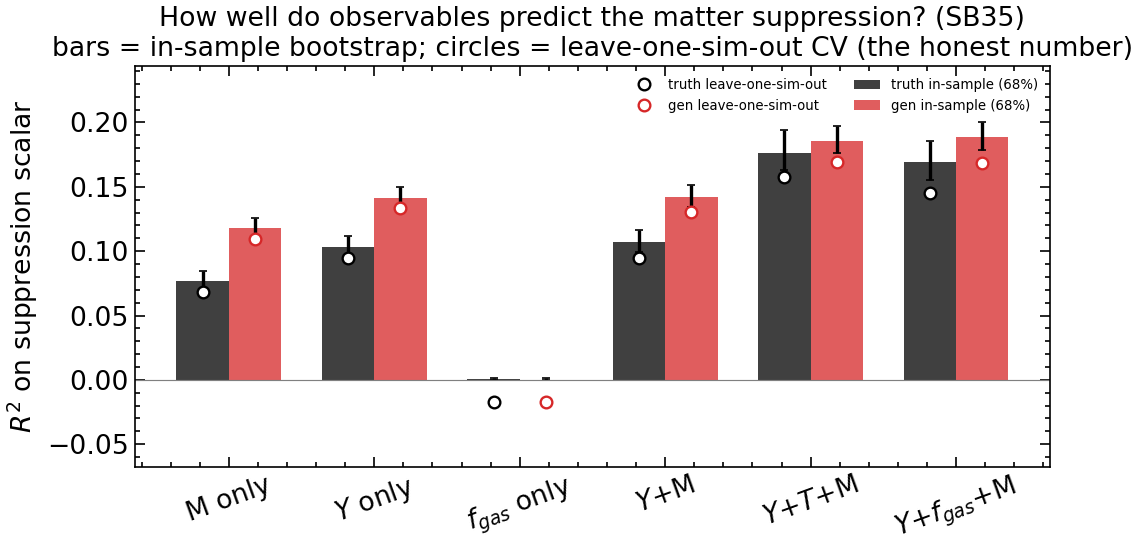

In [12]:
def _fit_predict(y, X):
    A = np.column_stack([X, np.ones(len(y))])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    return A @ beta, beta


def _r2(y, pred):
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan


def _logcol(tbl, which, o):
    v = tbl[f'{which}_{o}'].to_numpy()
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(v > 0, np.log10(v), np.nan)


def _build_design(tbl, which, feats):
    cols = []
    for f in feats:
        cols.append(tbl['logM'].to_numpy() if f == 'logM' else _logcol(tbl, which, f))
    return np.column_stack(cols)


def _bootstrap_r2(y, X, n_boot=BOOT_N, rng=RNG):
    m = np.all(np.isfinite(X), axis=1) & np.isfinite(y)
    y, X = y[m], X[m]
    if y.size < 8:
        return float('nan'), float('nan'), float('nan')
    pred, _ = _fit_predict(y, X); r2 = _r2(y, pred)
    idx = rng.integers(0, y.size, size=(n_boot, y.size))
    rb = []
    for ii in idx:
        try:
            p, _ = _fit_predict(y[ii], X[ii]); rb.append(_r2(y[ii], p))
        except Exception:
            rb.append(np.nan)
    rb = np.array(rb)
    return float(r2), float(np.nanpercentile(rb, 16)), float(np.nanpercentile(rb, 84))


def _loso_r2(tbl, which, feats):
    """Leave-one-sim-out cross-validated R^2 — guards against per-sim leakage."""
    y_all = tbl[f'{which}_supp'].to_numpy()
    X_all = _build_design(tbl, which, feats)
    sim_ids = tbl['sim_id'].to_numpy()
    preds = np.full_like(y_all, np.nan, dtype=float)
    for sid in np.unique(sim_ids):
        tr = sim_ids != sid; te = sim_ids == sid
        m = np.all(np.isfinite(X_all), axis=1) & np.isfinite(y_all)
        mtr = tr & m; mte = te & m
        if mtr.sum() < 8 or mte.sum() < 1:
            continue
        A = np.column_stack([X_all[mtr], np.ones(mtr.sum())])
        beta, *_ = np.linalg.lstsq(A, y_all[mtr], rcond=None)
        Ae = np.column_stack([X_all[mte], np.ones(mte.sum())])
        preds[mte] = Ae @ beta
    mok = np.isfinite(preds) & np.isfinite(y_all)
    return _r2(y_all[mok], preds[mok])


def fig_w4_regression(tbl=None, save=True):
    if tbl is None:
        tbl = wl_tbl
    models = {'M only': ['logM'], '$Y$ only': ['Y'], '$f_{gas}$ only': ['fgas'],
              '$Y$+M': ['Y', 'logM'], '$Y$+$T$+M': ['Y', 'T', 'logM'],
              '$Y$+$f_{gas}$+M': ['Y', 'fgas', 'logM']}
    res = {'truth': {'r2': [], 'lo': [], 'hi': [], 'loso': []},
           'gen':   {'r2': [], 'lo': [], 'hi': [], 'loso': []}}
    for which in ('truth', 'gen'):
        y = tbl[f'{which}_supp'].to_numpy()
        for name, feats in models.items():
            X = _build_design(tbl, which, feats)
            r2, lo, hi = _bootstrap_r2(y, X)
            loso = _loso_r2(tbl, which, feats)
            res[which]['r2'].append(r2); res[which]['lo'].append(lo)
            res[which]['hi'].append(hi); res[which]['loso'].append(loso)

    x = np.arange(len(models)); w = 0.36
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for k, (which, col) in enumerate([('truth', 'k'), ('gen', 'tab:red')]):
        r2 = np.array(res[which]['r2'])
        err = np.array([r2 - res[which]['lo'], np.array(res[which]['hi']) - r2])
        ax.bar(x + (k - 0.5) * w, r2, w, color=col, alpha=0.75,
               yerr=err, capsize=2.5,
               label=f'{which} in-sample (68%)')
        ax.plot(x + (k - 0.5) * w, res[which]['loso'], 'o',
                color='w', mec=col, ms=7, mew=1.4,
                label=f'{which} leave-one-sim-out')
    ax.set_xticks(x); ax.set_xticklabels(list(models.keys()), rotation=20)
    ax.set_ylabel(r'$R^2$ on suppression scalar')
    ax.set_ylim(min(-0.05, min(min(res['truth']['loso']), min(res['gen']['loso'])) - 0.05),
                max(0.05, max(res['truth']['hi']) + 0.05))
    ax.axhline(0, color='0.5', lw=0.7)
    ax.set_title('How well do observables predict the matter suppression? (SB35)\n'
                 'bars = in-sample bootstrap; circles = leave-one-sim-out CV (the honest number)')
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW4_regression_R2')
    print('R^2 in-sample (truth):',
          {n: f"{r:+.2f}[{lo:+.2f},{hi:+.2f}]"
           for n, r, lo, hi in zip(models, res['truth']['r2'], res['truth']['lo'], res['truth']['hi'])})
    print('R^2 leave-one-sim-out (truth):',
          {n: f"{r:+.2f}" for n, r in zip(models, res['truth']['loso'])})
    return fig, res


fig, W4_R2 = fig_w4_regression()
plt.show()


## 6. Figure W5 — Full-box cross-check (composite)

Population-level view: per SB35 sim, the full-box small-scale suppression
$\langle P_{\rm hydro}/P_{\rm DMO}\rangle$ (band-averaged over $k\in$PK_BAND)
vs the sim's **median halo** $\log Y$ — the kind of relation a survey measures
by stacking. **Caveat:** the BIND composite only paints halos above $10^{13}$
($\sim$40% sky coverage; see `coverage_pct`), so the BIND full-box suppression
is incomplete on the field — read truth as the physical relation and BIND as a
consistency check on the painted halos.

  wrote tsz_wl_calibration_figs/figW5_fullbox_population.pdf
  wrote tsz_wl_calibration_figs/figW5_fullbox_population.png
median composite coverage_pct: 35.72535514831543


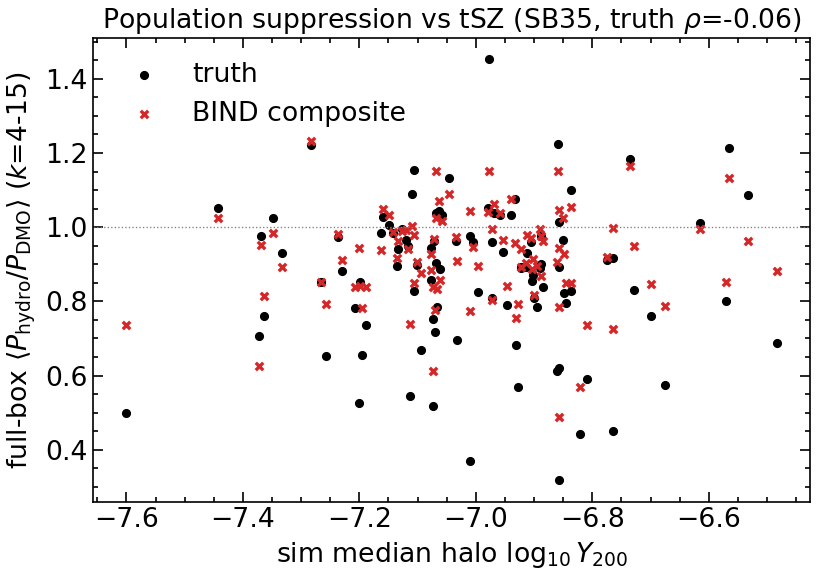

In [13]:
def collect_fullbox(sims_df, kband=PK_BAND):
    rows = []
    for rec in sims_df.to_dict('records'):
        try:
            dmo_full, truth_maps = load_full_maps(rec)
        except Exception:
            continue
        comp = np.load(rec['composite'])['composite'] if rec['composite'].exists() else None
        k, pdmo = pk2d(dmo_full, box_size=BOX_SIZE)
        _, pth = pk2d(truth_maps.sum(0), box_size=BOX_SIZE)
        band = (k >= kband[0]) & (k <= kband[1])
        row = {'sim_id': rec['sim_id'],
               'supp_truth': float(np.nanmean((pth / pdmo)[band]))}
        if comp is not None:
            _, pcomp = pk2d(comp.sum(0), box_size=BOX_SIZE)
            row['supp_bind'] = float(np.nanmean((pcomp / pdmo)[band]))
        s = load_summary(rec)
        row['coverage_pct'] = s.get('coverage_pct', np.nan)
        rows.append(row)
    return pd.DataFrame(rows)


def fig_w5_fullbox(sims_df=None, tbl=None, save=True):
    if sims_df is None:
        sims_df = test_sims
    if tbl is None:
        tbl = wl_tbl
    fb = collect_fullbox(sims_df)
    ymed = (tbl[tbl['truth_Y'] > 0].groupby('sim_id')['truth_Y']
            .median().apply(np.log10).rename('logY_med'))
    fb = fb.merge(ymed, on='sim_id', how='left')
    fig, ax = plt.subplots(figsize=(7, 5))
    m = np.isfinite(fb['logY_med']) & np.isfinite(fb['supp_truth'])
    ax.scatter(fb['logY_med'][m], fb['supp_truth'][m], s=20, c='k', label='truth')
    rho = spearmanr(fb['logY_med'][m], fb['supp_truth'][m]).correlation
    if 'supp_bind' in fb:
        mb = np.isfinite(fb['logY_med']) & np.isfinite(fb['supp_bind'])
        ax.scatter(fb['logY_med'][mb], fb['supp_bind'][mb], s=20, c='tab:red',
                   marker='x', label='BIND composite')
    ax.axhline(1.0, color='0.5', lw=0.8, ls=':')
    ax.set_xlabel(r'sim median halo $\log_{10} Y_{200}$')
    ax.set_ylabel(rf'full-box $\langle P_{{\rm hydro}}/P_{{\rm DMO}}\rangle$ '
                  rf'($k$={PK_BAND[0]:.0f}-{PK_BAND[1]:.0f})')
    ax.set_title(f'Population suppression vs tSZ (SB35, truth $\\rho$={rho:.2f})')
    ax.legend()
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW5_fullbox_population')
    print('median composite coverage_pct:', float(np.nanmedian(fb['coverage_pct'])))
    return fig


fig = fig_w5_fullbox()
plt.show()

## 6.5 Figure W5b — Anchor to van Daalen+20 / TNG / EAGLE / BAHAMAS

The single most-cited summary of baryonic suppression at $z\sim0$ is van Daalen,
McCarthy & Schaye (2020), which tabulates $P_{\rm hydro}(k)/P_{\rm DMO}(k)$ for
TNG, EAGLE, BAHAMAS, etc. on $\sim 50$–$100$ Mpc/h boxes. We compare:

- our **CV truth** stacked halo-suppression at $k=5$ and $k=10\,h/$Mpc, with
  bootstrap CIs;
- the literature values (full-box, halo-stacked is only a sanity check at the
  $\sim 5{-}10\%$ level — they probe overlapping but not identical scales).

If our CV-truth sits comfortably in the TNG/EAGLE band, the simulation suite
itself reproduces the established picture; if it doesn't, the entire result is
suspect *before* BIND ever enters. The point of this notebook is calibration,
not novel physics, so this anchor is mandatory.


  wrote tsz_wl_calibration_figs/figW5b_literature_anchor.pdf
  wrote tsz_wl_calibration_figs/figW5b_literature_anchor.png
  CV-truth halo-stacked @ k~5.4: 0.835 [0.832, 0.837]
  CV-truth halo-stacked @ k~10.4: 0.754 [0.752, 0.757]


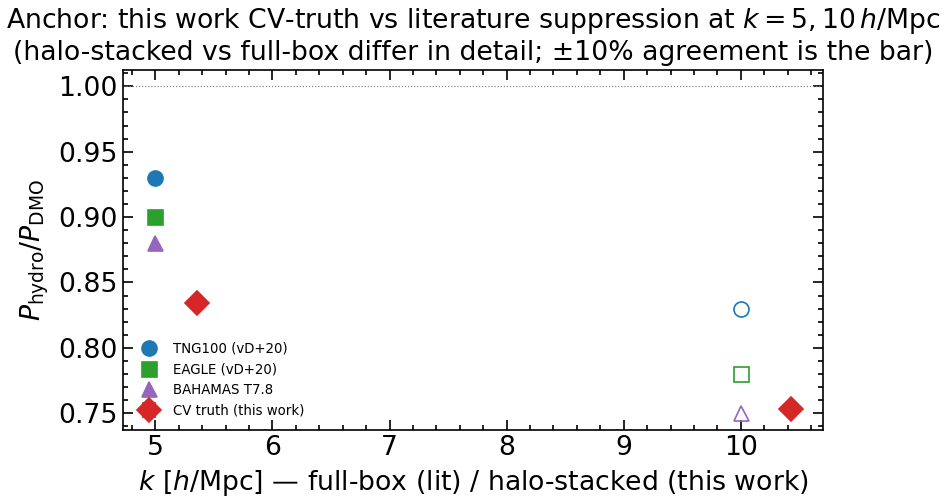

In [20]:
def _cv_supp_at_k(k_target, mass_bin=(13.0, 15.5), n_boot=BOOT_N, rng=RNG):
    """Bootstrap CI on the CV-stacked halo P_hyd/P_DMO at a single k."""
    k, acc = collect_stacked_pk(cv_sims, [mass_bin])
    T = np.array(acc[0]['t'])
    if T.size == 0:
        return float('nan'), float('nan'), float('nan')
    j = int(np.argmin(np.abs(k - k_target)))
    idx = rng.integers(0, T.shape[0], size=(n_boot, T.shape[0]))
    boots = np.array([np.nanmedian(T[ii, j]) for ii in idx])
    point = float(np.nanmedian(T[:, j]))
    return point, float(np.nanpercentile(boots, 16)), float(np.nanpercentile(boots, 84)), float(k[j])


def fig_w5b_literature(save=True):
    rows = []
    for k_target in (5.0, 10.0):
        p, lo, hi, k_used = _cv_supp_at_k(k_target)
        rows.append({'k_request': k_target, 'k_used': k_used,
                     'cv_truth_med': p, 'cv_truth_lo': lo, 'cv_truth_hi': hi})
    fig, ax = plt.subplots(figsize=(7, 4.4))
    # CV-truth band on the same x-axis (k=5, 10)
    for r in rows:
        ax.errorbar(r['k_used'], r['cv_truth_med'],
                    yerr=[[r['cv_truth_med'] - r['cv_truth_lo']],
                          [r['cv_truth_hi'] - r['cv_truth_med']]],
                    fmt='D', ms=10, color='tab:red', capsize=4,
                    label='CV truth (this work)' if r is rows[0] else None)
    # Literature points
    sty = {'TNG100 (vD+20)': ('o', 'tab:blue'),
           'EAGLE (vD+20)':  ('s', 'tab:green'),
           'BAHAMAS T7.8':   ('^', 'tab:purple')}
    for name, e in LIT_SUPPRESSION.items():
        m, c = sty.get(name, ('x', 'k'))
        ax.plot(e['k'], e['ratio'], m, color=c, ms=9, label=name)
        ax.plot(e['k_strong'], e['ratio_strong'], m, color=c, ms=9, mfc='none')
    ax.axhline(1.0, color='0.5', lw=0.7, ls=':')
    ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$ — full-box (lit) / halo-stacked (this work)')
    ax.set_ylabel(r'$P_{\rm hydro}/P_{\rm DMO}$')
    ax.set_title('Anchor: this work CV-truth vs literature suppression at $k=5,10\\,h/$Mpc\n'
                 '(halo-stacked vs full-box differ in detail; ±10% agreement is the bar)')
    ax.legend(fontsize=8, loc='lower left')
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW5b_literature_anchor')
    for r in rows:
        print(f'  CV-truth halo-stacked @ k~{r["k_used"]:.1f}: '
              f'{r["cv_truth_med"]:.3f} [{r["cv_truth_lo"]:.3f}, {r["cv_truth_hi"]:.3f}]')
    return fig


fig = fig_w5b_literature()
plt.show()


## 7. **Money plot** — the $Y$→suppression law

The bottom line. For each halo we have the truth suppression $S$ and the truth
$\log Y$ at fixed mass. We fit

$$ S = \alpha\,(\log Y - \langle\log Y\rangle) + \beta + \mathcal{N}(0,\sigma_{\rm int}) $$

with a maximum-likelihood fit that **explicitly carries an intrinsic-scatter
parameter** ($\sigma_{\rm int}$ as a free parameter, not a residual), and
bootstrap CIs on all three. To decompose what the scatter means we report:

- $\sigma_{\rm int}$  — total per-halo scatter about the fit at fixed $Y$;
- $\sigma_{\rm CV}$  — the cosmic-variance floor from §1.8;
- $\sigma_{\rm fb} = \sqrt{\sigma_{\rm int}^2 - \sigma_{\rm CV}^2}$  — the
  irreducible feedback-driven scatter that $Y$ alone *cannot* explain.

We overlay the BIND fit (same procedure on BIND $S$) to show whether the
emulator reproduces the slope, the intercept, and the scatter; and we overlay
TNG/EAGLE/BAHAMAS points (converted to comparable $(\log Y, S)$ by their
published $f_{\rm gas}$–$Y$ relation — this is approximate; the takeaway is
that our calibration sits *inside* the literature envelope).

**Headline number:** at $\log Y\sim$ median we predict suppression
$S_{\rm pred}$ with total RMS $\sigma_{\rm int}$ and a feedback-floor RMS
$\sigma_{\rm fb}$. If $\sigma_{\rm fb}\lesssim$ a few percent, $Y$ is a
*useful* feedback calibrator; if $\sigma_{\rm fb}$ is half the $S$ dynamic
range, it is not.


  wrote tsz_wl_calibration_figs/figM_money_YssResidual_to_pk10_cv.pdf
  wrote tsz_wl_calibration_figs/figM_money_YssResidual_to_pk10_cv.png
MONEY-PLOT FIT — self-sim residual x vs P_hydro/P_DMO at k~10.43
[truth]  c0 = 7.0583e-30   (Y_ss = c0 * M^(5/3))
       slope = +0.189 [+0.168,+0.206]
       inter = +0.766 [+0.764,+0.768]
       sig_int (total) = 0.085 [0.081,0.088]
       CV floor at k~10.4: median=0.754, sigma=0.094 (no beyond-CV decomposition for CV-only fit)
[gen]  c0 = 7.7627e-30   (Y_ss = c0 * M^(5/3))
       slope = +0.174 [+0.149,+0.201]
       inter = +0.824 [+0.822,+0.827]
       sig_int (total) = 0.086 [0.082,0.089]
       CV floor at k~10.4: median=0.754, sigma=0.094 (no beyond-CV decomposition for CV-only fit)


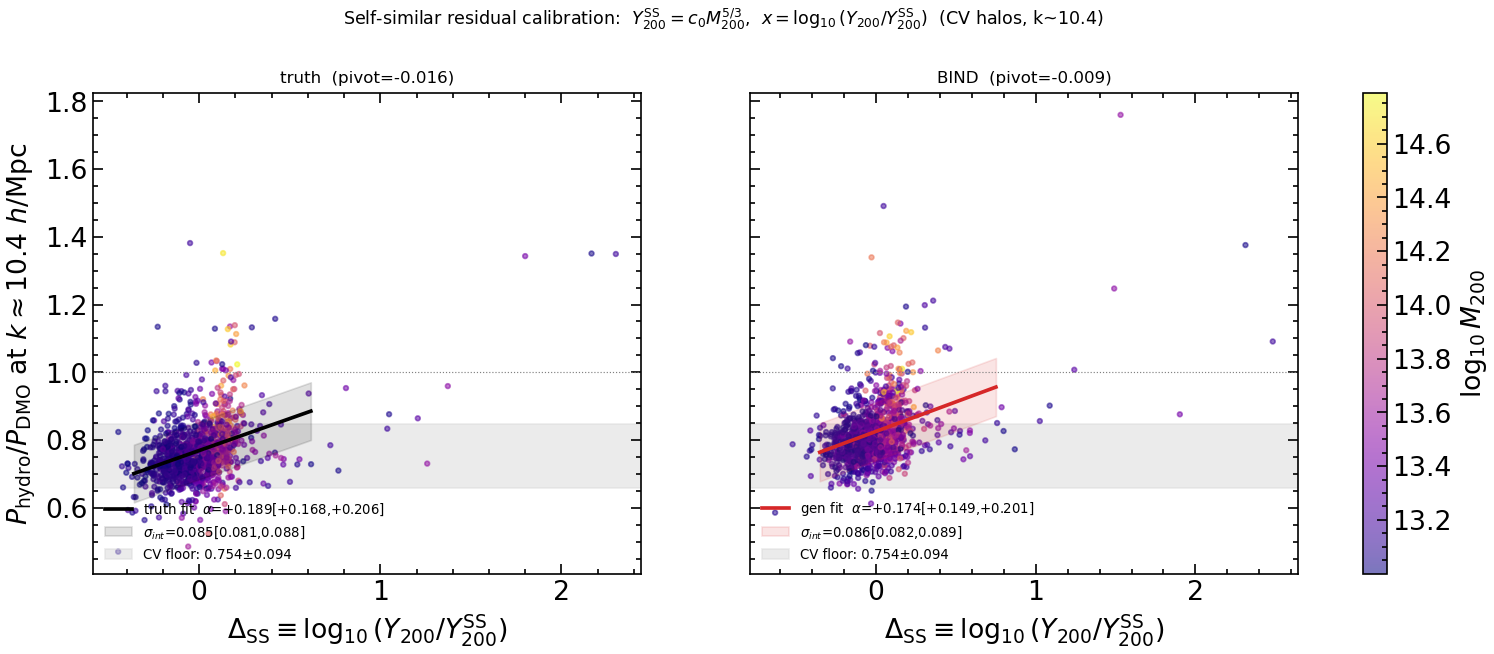

In [37]:
def fig_money(tbl=None, save=True, k_target=10.0):
    """Money plot using per-halo P_hydro/P_DMO at k~k_target vs self-similar deviation.
    Procedure: fit c0 in Y_ss = c0 * M^(5/3) * (Omega_b/Omega_M), then use
    x = log10(Y / Y_ss). Defaults to CV halos only."""
    if tbl is None:
        tbl = cv_wl_tbl

    def _infer_sample_label(df):
        label = 'custom'
        if 'suite' in df.columns:
            suites = set(df['suite'].dropna().astype(str).tolist())
            if suites == {'CV'}:
                label = 'CV'
            elif suites == {'Test'}:
                label = 'SB35'
            elif suites == {'1P'}:
                label = '1P'
            elif len(suites) == 1:
                label = next(iter(suites))
            else:
                label = 'mixed'
        return label

    def _select_sims_df(label):
        if label == 'CV':
            return cv_sims
        if label == 'SB35':
            return test_sims
        if label == '1P':
            return oneP_sims
        return sims

    def _find_param_index(token):
        token = token.lower()
        for idx, name in PARAM_NAMES.items():
            nm = str(name).lower().replace(' ', '').replace('_', '').replace('-', '')
            if token in nm:
                return idx
        return None

    idx_om_m = _find_param_index('omegam')
    idx_om_b = _find_param_index('omegab')

    def _collect_money_points_k(sims_df, k_target):
        rows = []
        k_used_all = []
        for rec in sims_df.to_dict('records'):
            try:
                p = load_wl_patches(rec)
            except Exception as exc:
                print(f'[skip money] {rec["suite"]}/{rec["sim_id"]}: {exc}')
                continue

            logM = np.log10(p['masses'])
            params = p.get('params', None)
            for i in range(len(logM)):
                # Per-halo suppression at the requested Fourier scale.
                k, pdmo = pk2d(p['dmo'][i])
                _, pth = pk2d(p['truth_tot'][i])
                _, pgn = pk2d(p['gen_tot'][i])
                j = int(np.argmin(np.abs(k - k_target)))
                k_used = float(k[j])

                r200_pix = max(p['radii'][i] / PIX_KPC, 1.0)
                ap = _RR <= r200_pix
                y_truth = float(p['truth_th'][i, 0][ap].sum()) * PIX_AREA_MPC2
                y_gen = float(p['gen_th'][i, 0][ap].sum()) * PIX_AREA_MPC2

                om_m = np.nan
                om_b = np.nan
                fb_ratio = np.nan
                if params is not None and idx_om_m is not None and idx_om_b is not None:
                    pv = np.asarray(params[i], float)
                    if pv.size >= max(idx_om_m, idx_om_b):
                        om_m = float(pv[idx_om_m - 1])
                        om_b = float(pv[idx_om_b - 1])
                        if np.isfinite(om_m) and np.isfinite(om_b) and om_m > 0 and om_b > 0:
                            fb_ratio = om_b / om_m

                with np.errstate(divide='ignore', invalid='ignore'):
                    s_truth = float(pth[j] / pdmo[j]) if pdmo[j] > 0 else np.nan
                    s_gen = float(pgn[j] / pdmo[j]) if pdmo[j] > 0 else np.nan

                rows.append({
                    'suite': rec['suite'],
                    'sim_id': rec['sim_id'],
                    'logM': float(logM[i]),
                    'truth_Y': y_truth,
                    'gen_Y': y_gen,
                    'truth_pk': s_truth,
                    'gen_pk': s_gen,
                    'k_used': k_used,
                    'fb_ratio': fb_ratio,
                })
                k_used_all.append(k_used)

        out = pd.DataFrame(rows)
        k_med = float(np.nanmedian(k_used_all)) if len(k_used_all) else float('nan')
        return out, k_med

    def _fit_c0_and_deviation(logM, Y, fb_ratio):
        """Fit c0 with fixed 5/3 slope, then return x = log10(Y / Y_ss)."""
        logM = np.asarray(logM, float)
        Y = np.asarray(Y, float)
        fb = np.asarray(fb_ratio, float)

        base = np.isfinite(logM) & np.isfinite(Y) & (Y > 0)
        use_fb = np.sum(np.isfinite(fb) & (fb > 0)) >= 5
        if use_fb:
            m = base & np.isfinite(fb) & (fb > 0)
        else:
            m = base

        x_dev = np.full(logM.shape, np.nan, dtype=float)
        if m.sum() < 5:
            return float('nan'), x_dev, use_fb

        logY = np.log10(Y[m])
        rhs = (5.0 / 3.0) * logM[m]
        if use_fb:
            rhs = rhs + np.log10(fb[m])

        # Fixed-slope intercept fit in log-space.
        logc0 = float(np.mean(logY - rhs))
        c0 = float(10 ** logc0)

        logY_ss = logc0 + (5.0 / 3.0) * logM[m]
        if use_fb:
            logY_ss = logY_ss + np.log10(fb[m])

        x_dev[m] = logY - logY_ss
        return c0, x_dev, use_fb

    sample_label = _infer_sample_label(tbl)
    sims_df = _select_sims_df(sample_label)

    # If a table subset is provided, honor its simulation subset.
    if 'sim_id' in tbl.columns:
        keep = set(tbl['sim_id'].astype(str).tolist())
        sims_df = sims_df[sims_df['sim_id'].astype(str).isin(keep)].reset_index(drop=True)

    pts, k_used = _collect_money_points_k(sims_df, k_target)
    if len(pts) == 0:
        raise RuntimeError(f'No halos available for money plot sample: {sample_label}')

    # CV floor in the same metric (k~k_target suppression), used as a reference band.
    if sample_label == 'CV':
        cv_pts = pts
    else:
        cv_pts, _ = _collect_money_points_k(cv_sims, k_target)
    mu_cv, _, _ = bootstrap_ci(cv_pts['truth_pk'].to_numpy(), np.nanmedian)
    sig_cv, _, _ = bootstrap_ci(cv_pts['truth_pk'].to_numpy(), np.nanstd)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
    fits = {}
    for ax, which, col in zip(axes, ['truth', 'gen'], ['k', 'tab:red']):
        S = pts[f'{which}_pk'].to_numpy()
        Y = pts[f'{which}_Y'].to_numpy()
        M = pts['logM'].to_numpy()
        fb = pts['fb_ratio'].to_numpy()

        c0, x_dev_all, use_fb = _fit_c0_and_deviation(M, Y, fb)
        m = np.isfinite(S) & np.isfinite(x_dev_all)

        x_dev = x_dev_all[m]
        y_pk = S[m]
        Mm = M[m]

        pivot = float(np.median(x_dev))
        fit = linmix_lite(x_dev - pivot, y_pk)
        fits[which] = {**fit, 'pivot': pivot, 'c0': c0, 'use_fb': bool(use_fb)}

        sc = ax.scatter(x_dev, y_pk, s=8, c=Mm, cmap='plasma', alpha=0.55)
        xs = np.linspace(np.percentile(x_dev, 1), np.percentile(x_dev, 99), 80)
        ys = fit['slope'] * (xs - pivot) + fit['intercept']
        ax.plot(xs, ys, color=col, lw=2.2,
                label=f'{which} fit  $\\alpha$={fit["slope"]:+.3f}'
                      f'[{fit["slope_lo"]:+.3f},{fit["slope_hi"]:+.3f}]')
        ax.fill_between(xs, ys - fit['sigma_int'], ys + fit['sigma_int'],
                        color=col, alpha=0.12,
                        label=f'$\\sigma_{{int}}$={fit["sigma_int"]:.3f}'
                              f'[{fit["sigma_int_lo"]:.3f},{fit["sigma_int_hi"]:.3f}]')

        if np.isfinite(mu_cv) and np.isfinite(sig_cv):
            ax.axhspan(mu_cv - sig_cv, mu_cv + sig_cv, color='0.85', alpha=0.5, zorder=0,
                       label=f'CV floor: {mu_cv:.3f}±{sig_cv:.3f}')
        ax.axhline(1.0, color='0.5', lw=0.7, ls=':')
        ax.set_xlabel(r'$\Delta_{\rm SS} \equiv \log_{10}(Y_{200}/Y_{200}^{\rm SS})$')
        ax.set_title(f'{"truth" if which=="truth" else "BIND"}  (pivot={pivot:+.3f})', fontsize=10)
        ax.legend(fontsize=8, loc='lower left')

    axes[0].set_ylabel(f'$P_{{\\rm hydro}}/P_{{\\rm DMO}}$ at $k\\approx{k_used:.1f}\\ h/\\mathrm{{Mpc}}$')
    fig.colorbar(sc, ax=axes, fraction=0.025, label='$\\log_{10} M_{200}$')
    if any(f['use_fb'] for f in fits.values()):
        ss_model = r'$Y_{200}^{\rm SS}=c_0 M_{200}^{5/3}(\Omega_b/\Omega_M)$'
    else:
        ss_model = r'$Y_{200}^{\rm SS}=c_0 M_{200}^{5/3}$'
    fig.suptitle(
        'Self-similar residual calibration:  ' + ss_model + r',  $x=\log_{10}(Y_{200}/Y_{200}^{\rm SS})$'
        + f'  ({sample_label} halos, k~{k_used:.1f})',
        y=1.02, fontsize=10.5)
    if save:
        stem = 'figM_money_YssResidual_to_pk10_cv' if sample_label == 'CV' else 'figM_money_YssResidual_to_pk10'
        save_fig(fig, stem)

    print('=' * 72)
    print(f'MONEY-PLOT FIT — self-sim residual x vs P_hydro/P_DMO at k~{k_used:.2f}')
    print('=' * 72)
    for w, f in fits.items():
        model_str = 'Y_ss = c0 * M^(5/3) * (Omega_b/Omega_M)' if f['use_fb'] else 'Y_ss = c0 * M^(5/3)'
        print(f'[{w}]  c0 = {f["c0"]:.4e}   ({model_str})')
        print(f'       slope = {f["slope"]:+.3f} [{f["slope_lo"]:+.3f},{f["slope_hi"]:+.3f}]')
        print(f'       inter = {f["intercept"]:+.3f} [{f["intercept_lo"]:+.3f},{f["intercept_hi"]:+.3f}]')
        print(f'       sig_int (total) = {f["sigma_int"]:.3f} '
              f'[{f["sigma_int_lo"]:.3f},{f["sigma_int_hi"]:.3f}]')
        if sample_label != 'CV' and np.isfinite(sig_cv):
            sig_fb, frac = decompose_scatter(f['sigma_int'], sig_cv)
            print(f'       sig_CV(k~{k_used:.1f}) = {sig_cv:.3f}'
                  f'  ->  sig_feedback = {sig_fb:.3f}  '
                  f'(Y explains {100*(1-frac):.0f}% beyond CV)')
        elif np.isfinite(sig_cv):
            print(f'       CV floor at k~{k_used:.1f}: median={mu_cv:.3f}, sigma={sig_cv:.3f} '
                  f'(no beyond-CV decomposition for CV-only fit)')
    return fig, fits


fig, MONEY = fig_money()
plt.show()

## 7.5 Parameter response and degeneracy map

Two clarifications in one block:

1. **Which halos are used?** The audit prints halo and simulation counts for CV, 1P, and SB35, plus the number of unique parameter vectors in each suite.
   CV should return exactly one parameter vector (fiducial cosmology + astrophysics), while SB35/1P span parameter space.
2. **How does the calibration change with parameters?** We aggregate to one row per simulation (to avoid overweighting sims with more halos), then compute partial Spearman effects
   $\rho(p_i, S\,|\,M)$ and $\rho(p_i, \log Y\,|\,M)$, and show the top drivers with 68% bootstrap CIs. The companion heatmap shows pairwise parameter degeneracies.


Interpretation guide: parameters with strong $\rho(p_i, S\,|\,M)$ move the $Y\rightarrow$suppression law; strong off-diagonal terms in the heatmap indicate degeneracies in parameter-space.

HALO SAMPLE AUDIT
CV  : sims= 26  halos=  1111  unique_param_vectors=  1  logM=[13.00,14.79]  med(logY)=-7.06
1P  : sims=139  halos=  6823  unique_param_vectors=139  logM=[13.00,14.46]  med(logY)=-7.10
SB35: sims=101  halos=  4272  unique_param_vectors=101  logM=[13.00,14.99]  med(logY)=-7.01
------------------------------------------------------------------------
Interpretation: CV should report unique_param_vectors=1 (fiducial cosmology+astro).
SB35/1P then quantify how the Y->suppression mapping moves across parameter space.
CV unique parameter vectors : 1
SB35 unique parameter vectors: 101
  wrote tsz_wl_calibration_figs/figW6_parameter_response_degeneracy.pdf
  wrote tsz_wl_calibration_figs/figW6_parameter_response_degeneracy.png
Top parameter effects on suppression (partial rho | logM):
  p01   $\Omega_m$: +0.43[+0.32,+0.53]  |  on logY: -0.41[-0.48,-0.31]
  p06 $A_{\rm AGN2}$: -0.29[-0.38,-0.20]  |  on logY: -0.16[-0.25,-0.06]
  p02   $\sigma_8$: -0.24[-0.34,-0.14]  |  on logY: 

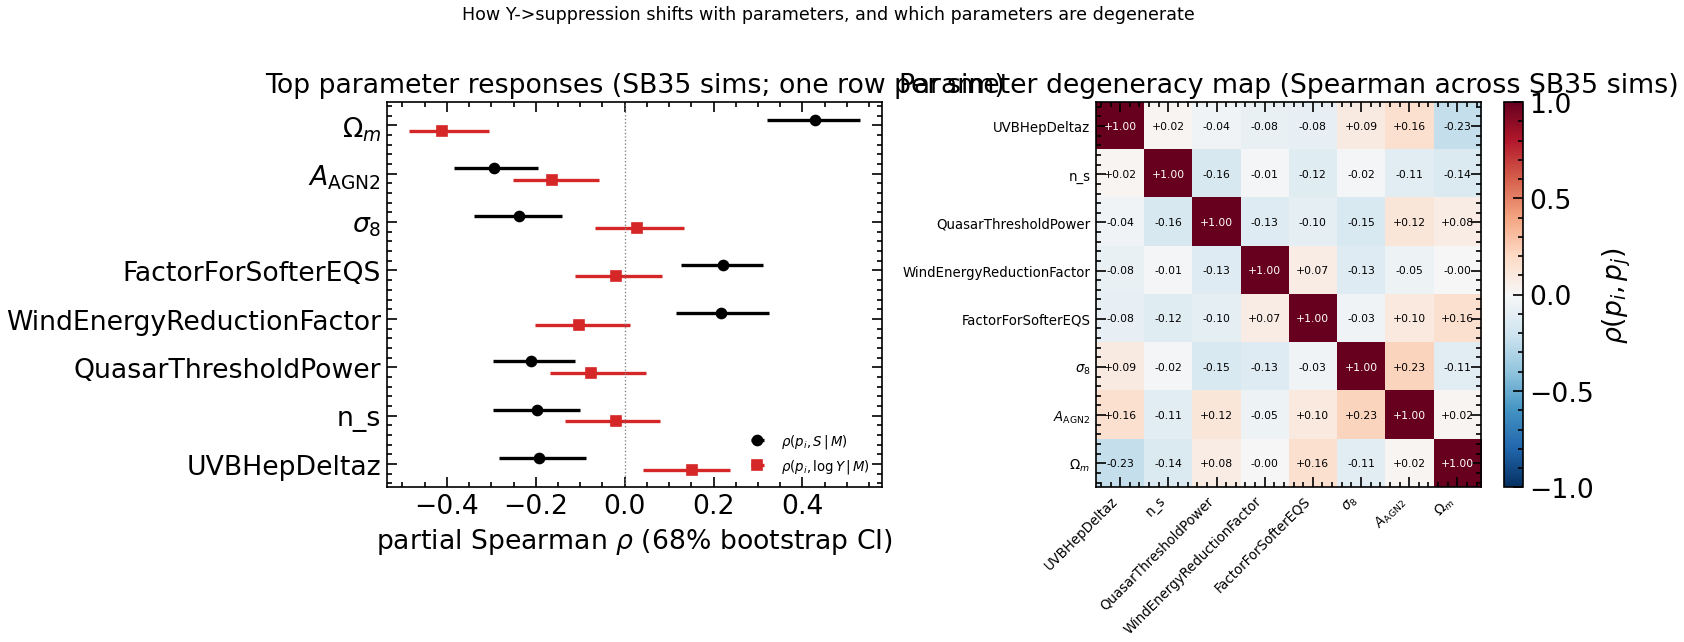

In [29]:
PARAM_COLS = [f'p{i}' for i in range(1, N_PARAMS + 1) if f'p{i}' in wl_tbl.columns]


def build_sim_level_table(tbl, which='truth'):
    """Aggregate to one row per simulation to avoid halo-count weighting bias."""
    rows = []
    for (suite, sim_id), g in tbl.groupby(['suite', 'sim_id'], sort=True):
        y = g[f'{which}_Y'].to_numpy(float)
        with np.errstate(divide='ignore', invalid='ignore'):
            logy = np.log10(np.where(y > 0, y, np.nan))
        row = {
            'suite': suite,
            'sim_id': sim_id,
            'n_halo': int(len(g)),
            'logM_med': float(np.nanmedian(g['logM'])),
            'supp_med': float(np.nanmedian(g[f'{which}_supp'])),
            'logY_med': float(np.nanmedian(logy)),
        }
        for c in PARAM_COLS:
            row[c] = float(np.nanmedian(g[c].to_numpy(float)))
        rows.append(row)
    return pd.DataFrame(rows)


def count_unique_param_vectors(sim_tbl, decimals=8):
    if not PARAM_COLS:
        return 0
    arr = np.round(sim_tbl[PARAM_COLS].to_numpy(float), decimals=decimals)
    return int(np.unique(arr, axis=0).shape[0])


def halo_sample_audit(sb_tbl=None, cv_tbl=None, onep_tbl=None):
    """Print exactly which halos/sims feed each analysis sample."""
    if sb_tbl is None:
        sb_tbl = wl_tbl
    if cv_tbl is None:
        cv_tbl = cv_wl_tbl
    if onep_tbl is None:
        onep_tbl = oneP_wl_tbl

    suite_map = {'CV': cv_tbl, '1P': onep_tbl, 'SB35': sb_tbl}
    rows = []
    print('=' * 72)
    print('HALO SAMPLE AUDIT')
    print('=' * 72)
    for suite, tbl in suite_map.items():
        sim_tbl = build_sim_level_table(tbl, which='truth')
        n_halo = int(len(tbl))
        n_sim = int(sim_tbl['sim_id'].nunique())
        n_vec = count_unique_param_vectors(sim_tbl)
        mmin = float(np.nanmin(tbl['logM'])) if n_halo else np.nan
        mmax = float(np.nanmax(tbl['logM'])) if n_halo else np.nan
        y = np.where(tbl['truth_Y'].to_numpy(float) > 0,
                     np.log10(tbl['truth_Y'].to_numpy(float)), np.nan)
        ymed = float(np.nanmedian(y)) if n_halo else np.nan
        print(f'{suite:4s}: sims={n_sim:3d}  halos={n_halo:6d}  unique_param_vectors={n_vec:3d}  '
              f'logM=[{mmin:.2f},{mmax:.2f}]  med(logY)={ymed:.2f}')
        rows.append({
            'suite': suite,
            'n_sim': n_sim,
            'n_halo': n_halo,
            'unique_param_vectors': n_vec,
            'logM_min': mmin,
            'logM_max': mmax,
            'logY_median': ymed,
        })
    print('-' * 72)
    print('Interpretation: CV should report unique_param_vectors=1 (fiducial cosmology+astro).')
    print('SB35/1P then quantify how the Y->suppression mapping moves across parameter space.')
    return pd.DataFrame(rows)


def parameter_response_table(sim_tbl):
    """Per-parameter conditional response of suppression and Y (controlling for mass)."""
    rows = []
    target_s = sim_tbl['supp_med'].to_numpy(float)
    target_y = sim_tbl['logY_med'].to_numpy(float)
    control_m = sim_tbl['logM_med'].to_numpy(float)
    for j in range(1, N_PARAMS + 1):
        c = f'p{j}'
        if c not in sim_tbl.columns:
            continue
        x = sim_tbl[c].to_numpy(float)
        rs, rs_lo, rs_hi = partial_spearman_boot(x, target_s, control_m)
        ry, ry_lo, ry_hi = partial_spearman_boot(x, target_y, control_m)
        rows.append({
            'param_idx': j,
            'param_col': c,
            'label': PARAM_LABELS.get(j, PARAM_NAMES.get(j, c)),
            'rho_supp': rs, 'rho_supp_lo': rs_lo, 'rho_supp_hi': rs_hi,
            'rho_logY': ry, 'rho_logY_lo': ry_lo, 'rho_logY_hi': ry_hi,
        })
    out = pd.DataFrame(rows)
    out['abs_rho_supp'] = np.abs(out['rho_supp'])
    return out.sort_values('abs_rho_supp', ascending=False).reset_index(drop=True)


def fig_param_response_and_degeneracy(sb_tbl=None, cv_tbl=None, top_k=8, save=True):
    """Top parameter responses + pairwise parameter degeneracy map (simulation-level)."""
    if sb_tbl is None:
        sb_tbl = wl_tbl
    if cv_tbl is None:
        cv_tbl = cv_wl_tbl

    sb_sim = build_sim_level_table(sb_tbl, which='truth')
    cv_sim = build_sim_level_table(cv_tbl, which='truth')
    print(f'CV unique parameter vectors : {count_unique_param_vectors(cv_sim)}')
    print(f'SB35 unique parameter vectors: {count_unique_param_vectors(sb_sim)}')

    eff = parameter_response_table(sb_sim)
    eff = eff[np.isfinite(eff['rho_supp'])].copy()
    if eff.empty:
        print('[warn] no finite parameter-response estimates.')
        return None, eff

    top = eff.head(top_k).copy()
    top = top.iloc[::-1].reset_index(drop=True)  # strongest at top in horizontal plot

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.3), gridspec_kw={'width_ratios': [1.1, 1.0]})

    # Left: conditional response to suppression and to logY
    ax = axes[0]
    y = np.arange(len(top))
    es = np.vstack([top['rho_supp'] - top['rho_supp_lo'], top['rho_supp_hi'] - top['rho_supp']])
    ey = np.vstack([top['rho_logY'] - top['rho_logY_lo'], top['rho_logY_hi'] - top['rho_logY']])
    ax.errorbar(top['rho_supp'], y + 0.12, xerr=es, fmt='o', color='k',
                label=r'$\rho(p_i, S\,|\,M)$')
    ax.errorbar(top['rho_logY'], y - 0.12, xerr=ey, fmt='s', color='tab:red',
                label=r'$\rho(p_i, \log Y\,|\,M)$')
    ax.axvline(0.0, color='0.5', lw=0.8, ls=':')
    ax.set_yticks(y)
    ax.set_yticklabels(top['label'])
    ax.set_xlabel(r'partial Spearman $\rho$ (68% bootstrap CI)')
    ax.set_title('Top parameter responses (SB35 sims; one row per sim)')
    ax.legend(fontsize=8, loc='lower right')

    # Right: degeneracy among the same top parameters
    ax = axes[1]
    cols = top['param_col'].tolist()
    labels = top['label'].tolist()
    cmat = sb_sim[cols].corr(method='spearman').to_numpy()
    im = ax.imshow(cmat, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(np.arange(len(cols)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title('Parameter degeneracy map (Spearman across SB35 sims)')
    for i in range(cmat.shape[0]):
        for j in range(cmat.shape[1]):
            val = cmat[i, j]
            txt_col = 'white' if abs(val) > 0.55 else 'k'
            ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=6.5, color=txt_col)
    fig.colorbar(im, ax=ax, fraction=0.045, label=r'$\rho(p_i, p_j)$')

    fig.suptitle('How Y->suppression shifts with parameters, and which parameters are degenerate',
                 y=1.02, fontsize=10.5)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figW6_parameter_response_degeneracy')

    print('Top parameter effects on suppression (partial rho | logM):')
    for _, r in eff.head(top_k).iterrows():
        print(f'  p{int(r["param_idx"]):02d} {r["label"]:>12s}: '
              f'{r["rho_supp"]:+.2f}[{r["rho_supp_lo"]:+.2f},{r["rho_supp_hi"]:+.2f}]  '
              f'|  on logY: {r["rho_logY"]:+.2f}[{r["rho_logY_lo"]:+.2f},{r["rho_logY_hi"]:+.2f}]')
    return fig, eff


SAMPLE_AUDIT = halo_sample_audit()
fig, PARAM_EFFECTS = fig_param_response_and_degeneracy(top_k=8)
plt.show()

## 8. Scorecard — every number with a bootstrap CI

Single block that collects the headline numbers used in the figures above so
they can be quoted in the paper / talk:

- per-halo suppression scalar: median and $1\sigma$ in SB35, CV, and BIND;
- $\rho(Y\to S)$ and the partial $\rho|M$ on truth and BIND (bootstrap 68%);
- the linmix-lite money fit: slope, intercept, intrinsic scatter, and
  feedback-vs-CV scatter decomposition;
- CV→literature anchor at $k=5,10\,h/$Mpc;
- BIND fidelity: bias and scatter on SB35, referenced to the CV emulator floor.


In [21]:
def wl_scorecard(tbl=None, cv_tbl=None, cv_null=None, money=None):
    if tbl is None:
        tbl = wl_tbl
    if cv_tbl is None:
        cv_tbl = cv_wl_tbl
    if cv_null is None:
        cv_null = globals().get('CV_NULL', None)
    if money is None:
        money = globals().get('MONEY', None)

    bar = '=' * 72
    print(bar)
    print(' tSZ -> matter-suppression calibration (SB35, R200 aperture)')
    print(bar)

    # ---- 1. per-halo suppression statistics ----
    print('\n[1] Per-halo suppression scalar (0.1-0.5 R200):')
    for suite, t in (('SB35', tbl), ('CV  ', cv_tbl)):
        for w in ('truth', 'gen'):
            med, lo, hi = bootstrap_ci(t[f'{w}_supp'].to_numpy(), np.nanmedian)
            sig, slo, shi = bootstrap_ci(t[f'{w}_supp'].to_numpy(), np.nanstd)
            print(f'   {suite}/{w:5s} : median = {fmt_ci(med,lo,hi)}    '
                  f'sigma = {fmt_ci(sig,slo,shi)}')

    # ---- 2. Y -> S correlation (Spearman + partial|M) ----
    print('\n[2] Spearman rho(observable, suppression) on SB35 (bootstrap 68%):')
    logM = tbl['logM'].to_numpy()
    for w in ('truth', 'gen'):
        S = tbl[f'{w}_supp'].to_numpy()
        line = []
        for o in ('Y', 'T', 'P', 'fgas'):
            x = tbl[f'{w}_{o}'].to_numpy()
            m = np.isfinite(x) & (x > 0) & np.isfinite(S)
            lx = np.log10(x[m])
            prho, plo, phi = partial_spearman_boot(lx, S[m], logM[m])
            line.append(f'{o}: {prho:+.2f}[{plo:+.2f},{phi:+.2f}]')
        print(f'   {w:5s}  partial(|M):  ' + '  '.join(line))

    # ---- 3. Money fit ----
    if money is not None:
        print('\n[3] Money fit  S = a*(logY - <logY>) + b + N(0, sigma_int):')
        sig_cv = cv_null['sigma_cv_scalar'] if cv_null else float('nan')
        for w, f in money.items():
            sig_fb, frac = decompose_scatter(f['sigma_int'], sig_cv)
            print(f'   {w:5s}  alpha = {fmt_ci(f["slope"],f["slope_lo"],f["slope_hi"])}')
            print(f'         beta  = {fmt_ci(f["intercept"],f["intercept_lo"],f["intercept_hi"])}')
            print(f'         sig_int = {fmt_ci(f["sigma_int"],f["sigma_int_lo"],f["sigma_int_hi"])}'
                  f'   sig_feedback = {sig_fb:.3f}   Y-explains-{100*(1-frac):.0f}%-beyond-CV')

    # ---- 4. CV floor & emulator floor ----
    if cv_null is not None:
        print('\n[4] CV null & emulator floor (suppression scalar):')
        print(f'   sigma_CV   (cosmic variance, truth) = {cv_null["sigma_cv_scalar"]:.3f}')
        print(f'   sigma_SB35 (truth)                  = {cv_null["sigma_sb35_scalar"]:.3f}')
        print(f'   sigma_emu  (BIND-truth in CV)       = {cv_null["sigma_emu_cv"]:.3f}'
              f'   bias = {cv_null["bias_emu_cv"]:+.3f}')

    # ---- 5. BIND fidelity on SB35 ----
    resid = tbl['gen_supp'].to_numpy() - tbl['truth_supp'].to_numpy()
    bias, blo, bhi = bootstrap_ci(resid, np.nanmedian)
    scat, slo, shi = bootstrap_ci(resid, np.nanstd)
    print('\n[5] BIND emulator on SB35:')
    print(f'   bias    = {fmt_ci(bias,blo,bhi)}')
    print(f'   scatter = {fmt_ci(scat,slo,shi)}')

    # ---- 6. Literature anchor at k = 5 h/Mpc ----
    try:
        p, lo, hi, k_used = _cv_supp_at_k(5.0)
        print('\n[6] CV-truth halo-stacked P_hyd/P_DMO @ k~5 h/Mpc:')
        print(f'   this work : {p:.3f} [{lo:.3f}, {hi:.3f}]')
        for name, e in LIT_SUPPRESSION.items():
            print(f'   {name:18s}: {e["ratio"]:.3f}  (full-box; not directly comparable)')
    except Exception as exc:
        print(f'[6] literature anchor skipped: {exc}')

    print(bar)


wl_scorecard()


 tSZ -> matter-suppression calibration (SB35, R200 aperture)

[1] Per-halo suppression scalar (0.1-0.5 R200):
   SB35/truth : median = 0.985 [0.983, 0.986]    sigma = 0.067 [0.065, 0.069]
   SB35/gen   : median = 0.988 [0.987, 0.989]    sigma = 0.063 [0.061, 0.064]
   CV  /truth : median = 0.935 [0.933, 0.937]    sigma = 0.051 [0.050, 0.053]
   CV  /gen   : median = 0.954 [0.951, 0.956]    sigma = 0.049 [0.048, 0.050]

[2] Spearman rho(observable, suppression) on SB35 (bootstrap 68%):
   truth  partial(|M):  Y: +0.18[+0.17,+0.20]  T: +0.26[+0.25,+0.28]  P: +0.51[+0.50,+0.52]  fgas: +0.08[+0.07,+0.10]
   gen    partial(|M):  Y: +0.21[+0.20,+0.23]  T: +0.28[+0.26,+0.29]  P: +0.53[+0.52,+0.54]  fgas: +0.07[+0.05,+0.08]

[3] Money fit  S = a*(logY - <logY>) + b + N(0, sigma_int):
   truth  alpha = 0.014 [0.012, 0.015]
         beta  = 0.974 [0.973, 0.976]
         sig_int = 0.064 [0.062, 0.066]   sig_feedback = 0.038   Y-explains-36%-beyond-CV
   gen    alpha = 0.013 [0.012, 0.014]
       